<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
  <!-- Left Column: Image -->
  <div style="flex: 1; text-align: center;">
    <img src="https://i0.wp.com/cdcs.web.ua.pt/wp-content/uploads/2022/05/cropped-cropped-Picture13-1.png?w=968" width="370" height="200" style="display: block; margin: auto;"/>
  </div>

  <!-- Right Column: Text -->
  <div style="flex: 1; text-align: left;">
    <div><strong style="color: #4F5B63; font-size: 1.5em;">Master in Data Science for Social Sciences</strong></div>
    <div><strong style="color: #4F5B63; font-size: 1.2em;">University of Aveiro</strong></div>
    <p style="color: #46627F; font-weight: bold; font-style: italic;">Statistics and Optimization for Decision Support - 2025/2026</p>
    <p style="color: #4F5B63;"></p>
    <p style="color: #4F5B63;">Paulo Batista</p>
  </div>
</div>

<div style="display: flex; justify-content: space-around; align-items: flex-start;">
  <div style="width: 100%; padding: 10px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); margin: 10px;">
    <h2><h1 style="text-align: center; font-size: 4em; color: #46627F; margin-top: 0; margin-bottom: 0; line-height: 1;">Block 3</h1>
    <p>
<h1 style="text-align: center; color: #B1C0CF; margin-top: 0; margin-bottom: 0; line-height: 1;"> - Introduction to Multivariate Analysis - Part 3 - </h1>
</p>

</h2>
      </div>
</div>

# EOAD 20252026 - Block III

Mestrado em Ciência dos Dados para Ciências Sociais <br>
Estatística e Optimização para Apoio à Decisão



In [47]:
from pathlib import Path
import sys
import os

In [48]:
# Core stats libs
import scipy.stats as stats
from scipy.linalg import eigh  # for eigenvalues/eigenvectors
import statsmodels.api as sm
from statsmodels.multivariate.pca import PCA as SM_PCA
from statsmodels.multivariate.factor import Factor
# Optional but useful for FA diagnostics (install via: pip install factor_analyzer)
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

In [49]:
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
from sklearn.preprocessing import StandardScaler 

In [51]:

#clusters
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch

#regression
from statsmodels.compat import lzip
import statsmodels.api as sm
from statsmodels.formula.api import ols


from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm
import pylab as py

import warnings

# Suppress warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")


In [52]:
# Find the project root (assuming marker-based or script-relative path)
def find_project_root(marker="README.md"):
    current_dir = Path.cwd()
    while current_dir != current_dir.parent:  # Traverse up until root
        if (current_dir / marker).exists():
            return current_dir
        current_dir = current_dir.parent
    raise FileNotFoundError(f"Marker '{marker}' not found in any parent directory.")

project_root = find_project_root()
sys.path.append(str(project_root)) 

# Or use a relative path: project_root = Path(__file__).resolve().parent.parent
os.chdir(project_root)
print(f"Working directory set to: {project_root}")

Working directory set to: c:\Users\paulo\OneDrive\TRABALHO_AULAS\AL20252026\1S_MstCDCS_EOAD\EOAD_Stats_LabRepository


# IMPORT DATA

In [53]:
census_2021 = pd.read_excel(r"data\inputs\INE\CENSOS_2021\FS2021SeccaoTot\FS 2021 Seccao Tot.xlsx")

In [54]:
census_2021.iloc[[0,-1]]

,ORD,NUTS1,NUTS1 DSG,ORD NUTS2,NUTS2,NUTS2 DSG,NUTS3,NUTS3 DSG,MUNICIPIO,MUNICIPIO DSG,...,N_INDIVIDUOS_DESEMPREGADOS_1EMP_M,N_INDIVIDUOS_DESEMPREGADOS_NOVOEMP_M,N_INDIVIDUOS_ESTUDANTES_M,N_INDIVIDUOS_DOMESTICOS_M,N_INDIVIDUOS_REFORMADOS_M,N_INDIVIDUOS_EMPREG_SECT_PRIM_M,N_INDIVIDUOS_EMPREG_SECT_SEC_M,N_INDIVIDUOS_EMPREG_SECT_TERC_M,N_INDIVIDUOS_NAC_ESTRANGEIRA_M,N_INDIVIDUOS_RESID_FORA_PAIS_M
0,1,PT,Portugal,0,NaN,Total,NaN,Total,NaN,Total,...,20616,191959,341996,285473,1317122,36070,324795,1809070,276593,1051733
13836,13837,3,Região Autónoma da Madeira,7,30.0,Região Autónoma da Madeira,300,Região Autónoma da Madeira,3201.0,Porto Santo,...,2,30,54,29,52,0,4,141,40,83


In [55]:
census_2021.columns.tolist()

['ORD',
 'NUTS1',
 'NUTS1 DSG',
 'ORD NUTS2',
 'NUTS2',
 'NUTS2 DSG',
 'NUTS3',
 'NUTS3 DSG',
 'MUNICIPIO',
 'MUNICIPIO DSG',
 'FREGUESIA',
 'FREGUESIA DSG',
 'SECCAO',
 'N_EDIFICIOS_CLASSICOS',
 'N_EDIFICIOS_CLASSICOS_1OU2_ALOJ',
 'N_EDIFICIOS_CLASSICOS_3OUMAIS_ALOJ',
 'N_EDIFICIOS_CLASSICOS_OUTRO',
 'N_EDIFICIOS_1OU2_PISOS',
 'N_EDIFICIOS_3OU4_PISOS',
 'N_EDIFICIOS_5OU_MAIS_PISOS',
 'N_EDIFICIOS_SEM_ELEVADOR',
 'N_EDIFICIOS_COM_ELEVADOR',
 'N_EDIFICIOS_EXCLUS_RESIDENCIAL',
 'N_EDIFICIOS_PINCIPAL_RESIDENCIAL',
 'N_EDIFICIOS_PINCIPAL_NAO_RESIDENCIAL',
 'N_EDIFICIOS_CONSTR_ANTES_1919',
 'N_EDIFICIOS_CONSTR_1919A1945',
 'N_EDIFICIOS_CONSTR_1946A1960',
 'N_EDIFICIOS_CONSTR_1961A1980',
 'N_EDIFICIOS_CONSTR_1981A1990',
 'N_EDIFICIOS_CONSTR_1991A2000',
 'N_EDIFICIOS_CONSTR_2001A2005',
 'N_EDIFICIOS_CONSTR_2006A2010',
 'N_EDIFICIOS_CONSTR_2011A2015',
 'N_EDIFICIOS_CONSTR_2016A2021',
 'N_EDIFICIOS_COM_NEC_REPARACAO',
 'N_EDIFICIOS_COM_NEC_REPARACAO_LIGEIRAS',
 'N_EDIFICIOS_COM_NEC_REPARACAO_ME

In [56]:
census_2021['SECCAO']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
13832    320101004
13833    320101005
13834    320101006
13835    320101007
13836    320101008
Name: SECCAO, Length: 13837, dtype: object

In [57]:
census_2021_FREG = census_2021[~census_2021['FREGUESIA'].isna() ].copy()
census_2021_FREG = census_2021_FREG[census_2021_FREG['SECCAO'].isna()]
census_2021_FREG = census_2021_FREG[census_2021_FREG['NUTS1'] == "1"]

In [58]:
census_2021_FREG.shape

(2882, 190)

In [59]:
census_2021_FREG.iloc[[0,-1]]

,ORD,NUTS1,NUTS1 DSG,ORD NUTS2,NUTS2,NUTS2 DSG,NUTS3,NUTS3 DSG,MUNICIPIO,MUNICIPIO DSG,...,N_INDIVIDUOS_DESEMPREGADOS_1EMP_M,N_INDIVIDUOS_DESEMPREGADOS_NOVOEMP_M,N_INDIVIDUOS_ESTUDANTES_M,N_INDIVIDUOS_DOMESTICOS_M,N_INDIVIDUOS_REFORMADOS_M,N_INDIVIDUOS_EMPREG_SECT_PRIM_M,N_INDIVIDUOS_EMPREG_SECT_SEC_M,N_INDIVIDUOS_EMPREG_SECT_TERC_M,N_INDIVIDUOS_NAC_ESTRANGEIRA_M,N_INDIVIDUOS_RESID_FORA_PAIS_M
5,6,1,Continente,1,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,...,1,3,11,23,57,2,8,39,1,39
13113,13114,1,Continente,4,18.0,Alentejo,187,Alentejo Central,714.0,Vila Viçosa,...,4,58,179,88,659,28,114,863,43,162


In [60]:
#total de casos e colunas
census_2021_FREG.shape

(2882, 190)

In [61]:
#designação das colunas
census_2021_FREG.columns

Index(['ORD', 'NUTS1', 'NUTS1 DSG', 'ORD NUTS2', 'NUTS2', 'NUTS2 DSG', 'NUTS3',
       'NUTS3 DSG', 'MUNICIPIO', 'MUNICIPIO DSG',
       ...
       'N_INDIVIDUOS_DESEMPREGADOS_1EMP_M',
       'N_INDIVIDUOS_DESEMPREGADOS_NOVOEMP_M', 'N_INDIVIDUOS_ESTUDANTES_M',
       'N_INDIVIDUOS_DOMESTICOS_M', 'N_INDIVIDUOS_REFORMADOS_M',
       'N_INDIVIDUOS_EMPREG_SECT_PRIM_M', 'N_INDIVIDUOS_EMPREG_SECT_SEC_M',
       'N_INDIVIDUOS_EMPREG_SECT_TERC_M', 'N_INDIVIDUOS_NAC_ESTRANGEIRA_M',
       'N_INDIVIDUOS_RESID_FORA_PAIS_M'],
      dtype='object', length=190)

In [62]:
#visualiza as primeiras linhas da base de dados
census_2021_FREG.head()

,ORD,NUTS1,NUTS1 DSG,ORD NUTS2,NUTS2,NUTS2 DSG,NUTS3,NUTS3 DSG,MUNICIPIO,MUNICIPIO DSG,...,N_INDIVIDUOS_DESEMPREGADOS_1EMP_M,N_INDIVIDUOS_DESEMPREGADOS_NOVOEMP_M,N_INDIVIDUOS_ESTUDANTES_M,N_INDIVIDUOS_DOMESTICOS_M,N_INDIVIDUOS_REFORMADOS_M,N_INDIVIDUOS_EMPREG_SECT_PRIM_M,N_INDIVIDUOS_EMPREG_SECT_SEC_M,N_INDIVIDUOS_EMPREG_SECT_TERC_M,N_INDIVIDUOS_NAC_ESTRANGEIRA_M,N_INDIVIDUOS_RESID_FORA_PAIS_M
5,6,1,Continente,1,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,...,1,3,11,23,57,2,8,39,1,39
7,8,1,Continente,1,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,...,1,5,20,48,110,6,27,75,5,97
9,10,1,Continente,1,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,...,0,3,5,17,35,3,5,26,3,29
11,12,1,Continente,1,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,...,0,1,2,14,52,2,4,9,3,43
13,14,1,Continente,1,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,...,0,1,7,9,86,4,5,16,2,28


In [63]:
#estatísticas descritivas de todas as variáveis
census_2021_FREG.describe()

,ORD,ORD NUTS2,NUTS2,MUNICIPIO,N_EDIFICIOS_CLASSICOS,N_EDIFICIOS_CLASSICOS_1OU2_ALOJ,N_EDIFICIOS_CLASSICOS_3OUMAIS_ALOJ,N_EDIFICIOS_CLASSICOS_OUTRO,N_EDIFICIOS_1OU2_PISOS,N_EDIFICIOS_3OU4_PISOS,...,N_INDIVIDUOS_DESEMPREGADOS_1EMP_M,N_INDIVIDUOS_DESEMPREGADOS_NOVOEMP_M,N_INDIVIDUOS_ESTUDANTES_M,N_INDIVIDUOS_DOMESTICOS_M,N_INDIVIDUOS_REFORMADOS_M,N_INDIVIDUOS_EMPREG_SECT_PRIM_M,N_INDIVIDUOS_EMPREG_SECT_SEC_M,N_INDIVIDUOS_EMPREG_SECT_TERC_M,N_INDIVIDUOS_NAC_ESTRANGEIRA_M,N_INDIVIDUOS_RESID_FORA_PAIS_M
count,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,...,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000,2882.000000
mean,5808.998612,1.823387,13.751214,979.405621,1173.479528,1071.992366,99.263359,2.223803,979.213740,156.418459,...,6.576336,63.534004,112.622831,92.924358,440.323040,11.882373,110.907703,595.459750,94.121790,350.768217
std,3730.984625,1.062618,2.791905,557.726955,1448.618108,1240.467782,318.463228,5.518221,1131.821114,329.207251,...,17.006458,166.168565,257.030958,166.943586,876.616141,22.902470,202.456009,1503.377364,339.376358,897.365606
min,6.000000,1.000000,11.000000,101.000000,99.000000,98.000000,0.000000,0.000000,38.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3227.500000,1.000000,11.000000,408.000000,387.000000,381.250000,0.000000,0.000000,344.000000,15.000000,...,0.000000,4.000000,10.000000,19.000000,83.000000,2.000000,6.000000,45.000000,3.000000,45.000000
50%,5131.500000,2.000000,15.000000,914.000000,687.000000,671.000000,2.000000,1.000000,619.000000,45.000000,...,1.000000,14.000000,30.000000,39.500000,168.000000,6.000000,29.000000,133.000000,9.000000,90.000000
75%,8565.250000,2.000000,16.000000,1504.750000,1345.500000,1249.750000,31.000000,2.000000,1138.000000,132.000000,...,5.000000,40.000000,85.000000,85.000000,367.000000,13.000000,124.000000,380.000000,30.000000,230.000000
max,13114.000000,5.000000,18.000000,1824.000000,17414.000000,16197.000000,3426.000000,121.000000,13992.000000,3915.000000,...,165.000000,1690.000000,2483.000000,2337.000000,8448.000000,659.000000,2373.000000,14797.000000,5658.000000,13279.000000


# DATASET SELECTION 
Create a *subset* of the initial 

In [64]:
column_names = census_2021_FREG.columns.tolist()
print(column_names)


['ORD', 'NUTS1', 'NUTS1 DSG', 'ORD NUTS2', 'NUTS2', 'NUTS2 DSG', 'NUTS3', 'NUTS3 DSG', 'MUNICIPIO', 'MUNICIPIO DSG', 'FREGUESIA', 'FREGUESIA DSG', 'SECCAO', 'N_EDIFICIOS_CLASSICOS', 'N_EDIFICIOS_CLASSICOS_1OU2_ALOJ', 'N_EDIFICIOS_CLASSICOS_3OUMAIS_ALOJ', 'N_EDIFICIOS_CLASSICOS_OUTRO', 'N_EDIFICIOS_1OU2_PISOS', 'N_EDIFICIOS_3OU4_PISOS', 'N_EDIFICIOS_5OU_MAIS_PISOS', 'N_EDIFICIOS_SEM_ELEVADOR', 'N_EDIFICIOS_COM_ELEVADOR', 'N_EDIFICIOS_EXCLUS_RESIDENCIAL', 'N_EDIFICIOS_PINCIPAL_RESIDENCIAL', 'N_EDIFICIOS_PINCIPAL_NAO_RESIDENCIAL', 'N_EDIFICIOS_CONSTR_ANTES_1919', 'N_EDIFICIOS_CONSTR_1919A1945', 'N_EDIFICIOS_CONSTR_1946A1960', 'N_EDIFICIOS_CONSTR_1961A1980', 'N_EDIFICIOS_CONSTR_1981A1990', 'N_EDIFICIOS_CONSTR_1991A2000', 'N_EDIFICIOS_CONSTR_2001A2005', 'N_EDIFICIOS_CONSTR_2006A2010', 'N_EDIFICIOS_CONSTR_2011A2015', 'N_EDIFICIOS_CONSTR_2016A2021', 'N_EDIFICIOS_COM_NEC_REPARACAO', 'N_EDIFICIOS_COM_NEC_REPARACAO_LIGEIRAS', 'N_EDIFICIOS_COM_NEC_REPARACAO_MEDIAS', 'N_EDIFICIOS_COM_NEC_REPARACAO

In [65]:
Municipios=census_2021_FREG['MUNICIPIO DSG'].unique()
Municipios

array(['Arcos de Valdevez', 'Caminha', 'Melgaço', 'Monção',
       'Paredes de Coura', 'Ponte da Barca', 'Ponte de Lima', 'Valença',
       'Viana do Castelo', 'Vila Nova de Cerveira', 'Amares', 'Barcelos',
       'Braga', 'Esposende', 'Terras de Bouro', 'Vila Verde',
       'Cabeceiras de Basto', 'Fafe', 'Guimarães', 'Póvoa de Lanhoso',
       'Vieira do Minho', 'Vila Nova de Famalicão', 'Vizela',
       'Mondim de Basto', 'Arouca', 'Espinho', 'Santa Maria da Feira',
       'Oliveira de Azeméis', 'São João da Madeira', 'Vale de Cambra',
       'Gondomar', 'Maia', 'Matosinhos', 'Paredes', 'Porto',
       'Póvoa de Varzim', 'Santo Tirso', 'Valongo', 'Vila do Conde',
       'Vila Nova de Gaia', 'Trofa', 'Boticas', 'Chaves', 'Montalegre',
       'Ribeira de Pena', 'Valpaços', 'Vila Pouca de Aguiar',
       'Castelo de Paiva', 'Celorico de Basto', 'Amarante', 'Baião',
       'Felgueiras', 'Lousada', 'Marco de Canaveses', 'Paços de Ferreira',
       'Penafiel', 'Cinfães', 'Resende', 'Carraz

# INDICATORS FROM THE INITIAL DATASET
From the original BGRI database, some composite indicators are constructed for statistical treatment

In [66]:
#criação de uma lista de indicadores compósitos 
indicators_list = ['IVolumetria', 
                   'vagos_perc', 
                   'IMédia_edif',
                   'aloj_habitual_perc', 
                   'dimensao_aloj', 
                   'aloj_por_familia', 
                   'arrendamento_perc', 
                   'divisões_n', 
                   'degradação_edif_perc',
                   'ind_envelhecimento', 
                   'ind_migração', 
                   'primário_perc', 
                   'terciário_perc']


In [67]:
df = census_2021_FREG

In [68]:
#Índice de volumetria do edificado (número de médio de pisos por unidade territorial)
total_edificios = (df.N_EDIFICIOS_1OU2_PISOS)+(df.N_EDIFICIOS_3OU4_PISOS)+(df.N_EDIFICIOS_5OU_MAIS_PISOS)
volumetria = ((df.N_EDIFICIOS_1OU2_PISOS*1.5)+(df.N_EDIFICIOS_3OU4_PISOS*3.5)+(df.N_EDIFICIOS_5OU_MAIS_PISOS*7))
df["IVolumetria"] = volumetria/total_edificios
df["IVolumetria"]

5        1.636986
7        1.692872
9        1.640351
11       1.562802
13       1.630854
           ...   
13103    1.513986
13106    1.502119
13109    1.512442
13111    1.543785
13113    1.727296
Name: IVolumetria, Length: 2882, dtype: float64

In [69]:
#alojamentos vagos (valor percentual de alojamentos vagos por unidade territorial)
df["vagos_perc"]=df['N_ALOJAMENTOS_VAGOS_TOTAL']/df['N_ALOJAMENTOS_TOTAL']
df["vagos_perc"]

5        0.136364
7        0.110429
9        0.057143
11       0.223022
13       0.142077
           ...   
13103    0.178241
13106    0.104401
13109    0.070588
13111    0.144737
13113    0.155333
Name: vagos_perc, Length: 2882, dtype: float64

In [70]:
#média de anos do edificado (idade média do edificado por unidade territorial)
total_edificios = (df.N_EDIFICIOS_CONSTR_ANTES_1919)+(df.N_EDIFICIOS_CONSTR_1919A1945)+(df.N_EDIFICIOS_CONSTR_1946A1960)+(df.N_EDIFICIOS_CONSTR_1961A1980)+(df.N_EDIFICIOS_CONSTR_1981A1990)+(df.N_EDIFICIOS_CONSTR_1991A2000)+(df.N_EDIFICIOS_CONSTR_2001A2005)+(df.N_EDIFICIOS_CONSTR_2006A2010)+(df.N_EDIFICIOS_CONSTR_2011A2015)+(df.N_EDIFICIOS_CONSTR_2016A2021)
df['IMédia_edif'] = (((2021-1910)*df.N_EDIFICIOS_CONSTR_ANTES_1919)+((2021-1932)*df.N_EDIFICIOS_CONSTR_1919A1945)+((2021-1953)*df.N_EDIFICIOS_CONSTR_1946A1960)+((2021-1970)*df.N_EDIFICIOS_CONSTR_1961A1980)+((2021-1985.5)*df.N_EDIFICIOS_CONSTR_1981A1990)+((2021-1995.5)*df.N_EDIFICIOS_CONSTR_1991A2000)+((2021-2003)*df.N_EDIFICIOS_CONSTR_2001A2005)+((2021-2008)*df.N_EDIFICIOS_CONSTR_2006A2010) + ((2021-2013)*df.N_EDIFICIOS_CONSTR_2011A2015) + ((2021-2018.5)*df.N_EDIFICIOS_CONSTR_2016A2021))/total_edificios
df['IMédia_edif']

5        52.577626
7        34.557652
9        46.853801
11       52.317633
13       67.353994
           ...    
13103    43.462704
13106    59.226695
13109    54.166407
13111    44.781073
13113    54.259767
Name: IMédia_edif, Length: 2882, dtype: float64

In [71]:
#alojamento de residencia habitual (principal) (percentagem de alojamentos de residência habitual por unidade territorial)
df["aloj_habitual_perc"]= df["N_CLASSICOS_RES_HABITUAL"]/df["N_ALOJAMENTOS_TOTAL"]
df["aloj_habitual_perc"]

5        0.536364
7        0.566462
9        0.502857
11       0.242206
13       0.478142
           ...   
13103    0.724537
13106    0.650972
13109    0.548529
13111    0.521053
13113    0.710451
Name: aloj_habitual_perc, Length: 2882, dtype: float64

In [72]:
#dimensão média dos alojamentos (dimensão média dos alojamentos em metros quadrados por unidade territorial)
total_edificios = (df.N_RHABITUAL_AREA_49)+(df.N_RHABITUAL_AREA_50_99)+(df.N_RHABITUAL_AREA_100_149)+(df.N_RHABITUAL_AREA_150_199)+(df.N_RHABITUAL_AREA_200MAIS)
dimensao = ((df.N_RHABITUAL_AREA_49*25)+(df.N_RHABITUAL_AREA_50_99*75)+(df.N_RHABITUAL_AREA_100_149*150)+(df.N_RHABITUAL_AREA_150_199*200)+(df.N_RHABITUAL_AREA_200MAIS*300))
df["dimensao_aloj"]=dimensao/total_edificios
df["dimensao_aloj"]

5        143.220339
7        146.119134
9        144.886364
11       128.712871
13       119.714286
            ...    
13103    156.948882
13106    121.619497
13109    118.900804
13111    140.151515
13113    127.367758
Name: dimensao_aloj, Length: 2882, dtype: float64

In [73]:
#alojamento por família (número de alojamento por agregado familiar por unidade territorial)
df["aloj_por_familia"]= df["N_ALOJAMENTOS_TOTAL"]/df["N_AGREGADOS_DOMESTICOS_PRIVADOS"]
df["aloj_por_familia"]

5        1.864407
7        1.765343
9        1.988636
11       4.128713
13       2.091429
           ...   
13103    1.380192
13106    1.533752
13109    1.823056
13111    1.919192
13113    1.406848
Name: aloj_por_familia, Length: 2882, dtype: float64

In [74]:
#percentagem do arrendamento (percentagem de alojamentos em regime de arrendamento por unidade territorial)
df["arrendamento_perc"]= df["N_RHABITUAL_ARRENDADOS"]/df["N_ALOJAMENTOS_FAMILIARES"]
df["arrendamento_perc"]

5        0.000000
7        0.030675
9        0.011429
11       0.004796
13       0.002732
           ...   
13103    0.030162
13106    0.157625
13109    0.050074
13111    0.073684
13113    0.177124
Name: arrendamento_perc, Length: 2882, dtype: float64

In [75]:
df.columns.tolist()

['ORD',
 'NUTS1',
 'NUTS1 DSG',
 'ORD NUTS2',
 'NUTS2',
 'NUTS2 DSG',
 'NUTS3',
 'NUTS3 DSG',
 'MUNICIPIO',
 'MUNICIPIO DSG',
 'FREGUESIA',
 'FREGUESIA DSG',
 'SECCAO',
 'N_EDIFICIOS_CLASSICOS',
 'N_EDIFICIOS_CLASSICOS_1OU2_ALOJ',
 'N_EDIFICIOS_CLASSICOS_3OUMAIS_ALOJ',
 'N_EDIFICIOS_CLASSICOS_OUTRO',
 'N_EDIFICIOS_1OU2_PISOS',
 'N_EDIFICIOS_3OU4_PISOS',
 'N_EDIFICIOS_5OU_MAIS_PISOS',
 'N_EDIFICIOS_SEM_ELEVADOR',
 'N_EDIFICIOS_COM_ELEVADOR',
 'N_EDIFICIOS_EXCLUS_RESIDENCIAL',
 'N_EDIFICIOS_PINCIPAL_RESIDENCIAL',
 'N_EDIFICIOS_PINCIPAL_NAO_RESIDENCIAL',
 'N_EDIFICIOS_CONSTR_ANTES_1919',
 'N_EDIFICIOS_CONSTR_1919A1945',
 'N_EDIFICIOS_CONSTR_1946A1960',
 'N_EDIFICIOS_CONSTR_1961A1980',
 'N_EDIFICIOS_CONSTR_1981A1990',
 'N_EDIFICIOS_CONSTR_1991A2000',
 'N_EDIFICIOS_CONSTR_2001A2005',
 'N_EDIFICIOS_CONSTR_2006A2010',
 'N_EDIFICIOS_CONSTR_2011A2015',
 'N_EDIFICIOS_CONSTR_2016A2021',
 'N_EDIFICIOS_COM_NEC_REPARACAO',
 'N_EDIFICIOS_COM_NEC_REPARACAO_LIGEIRAS',
 'N_EDIFICIOS_COM_NEC_REPARACAO_ME

In [76]:
df["degradação_edif_perc"]= df["N_EDIFICIOS_COM_NEC_REPARACAO"]/df["N_EDIFICIOS_CLASSICOS"]

In [77]:
#número médio de divisões (número médio de divisões de cada  alojamentos por unidade territorial)
total_edificios = (df.N_RHABITUAL_1_2_DIV) + (df.N_RHABITUAL_3_4_DIV) + (df.N_RHABITUAL_5_MAIS_DIV)
total_divisões = (df.N_RHABITUAL_1_2_DIV * 1.5) + (df.N_RHABITUAL_3_4_DIV * 3.5) + (df.N_RHABITUAL_5_MAIS_DIV * 5)
df["divisões_n"] = total_divisões/total_edificios
df["divisões_n"]

5        3.864407
7        3.830325
9        3.863636
11       3.801980
13       3.631429
           ...   
13103    3.892971
13106    3.577830
13109    3.652815
13111    3.704545
13113    3.817632
Name: divisões_n, Length: 2882, dtype: float64

In [78]:
#Indice de envelhecimento = [pop com mais de 65 anos / pop até 20 anos]*100
df["ind_envelhecimento"]= (df.N_INDIVIDUOS_65_OU_MAIS)/(df.N_INDIVIDUOS_0A4+df.N_INDIVIDUOS_5A9+df.N_INDIVIDUOS_10A14+df.N_INDIVIDUOS_15A19)*100
df["ind_envelhecimento"]

5         287.179487
7         220.192308
9         308.000000
11       1225.000000
13        823.809524
            ...     
13103      97.058824
13106     148.249027
13109     319.753086
13111     159.375000
13113     158.421053
Name: ind_envelhecimento, Length: 2882, dtype: float64

In [79]:
#indice de qualificação (número de anos de escolaridade da população)
total_população=(df.N_INDIVIDUO_ENSINCOMP_1BAS)+(df.N_INDIVIDUO_ENSINCOMP_2BAS)+(df.N_INDIVIDUO_ENSINCOMP_3BAS)+(df.N_INDIVIDUO_ENSINCOMP_SEC_E_POSSEC)+(df.N_INDIVIDUO_ENSINCOMP_SUP)
anos_escolaridade=(df.N_INDIVIDUO_ENSINCOMP_1BAS*4)+(df.N_INDIVIDUO_ENSINCOMP_2BAS*6)+(df.N_INDIVIDUO_ENSINCOMP_3BAS*9)+(df.N_INDIVIDUO_ENSINCOMP_SEC_E_POSSEC*12)+(df.N_INDIVIDUO_ENSINCOMP_SUP*14)
df["ind_qualificações"]=anos_escolaridade/total_população
df["ind_qualificações"]

5        7.310861
7        7.391379
9        7.429348
11       6.170213
13       6.711009
           ...   
13103    8.695291
13106    8.124587
13109    7.334324
13111    7.802030
13113    9.032940
Name: ind_qualificações, Length: 2882, dtype: float64

In [80]:
#Índice de ´migração´ (relação entre a população residnete e a população presente)
df["ind_migração"]=df['N_INDIVIDUOS_NAC_ESTRANGEIRA']/df['N_INDIVIDUOS']*100
df["ind_migração"]

5        1.016949
7        0.990099
9        2.415459
11       1.694915
13       0.617284
           ...   
13103    0.931315
13106    2.027027
13109    2.573529
13111    3.063457
13113    1.488994
Name: ind_migração, Length: 2882, dtype: float64

In [81]:
#Estrutura do emprego: primário
total_emprego=(df.N_INDIVIDUOS_EMPREG_SECT_PRIM)+(df.N_INDIVIDUOS_EMPREG_SECT_SEC)+(df.N_INDIVIDUOS_EMPREG_SECT_TERC)

#estrutura do emprego (primário)
df["primário_perc"]=df.N_INDIVIDUOS_EMPREG_SECT_PRIM/total_emprego
df["primário_perc"]

5        0.061224
7        0.032787
9        0.115385
11       0.117647
13       0.134615
           ...   
13103    0.082742
13106    0.091379
13109    0.170088
13111    0.093750
13113    0.043348
Name: primário_perc, Length: 2882, dtype: float64

In [82]:
#Estrutura do emprego: secundário
total_emprego=(df.N_INDIVIDUOS_EMPREG_SECT_PRIM)+(df.N_INDIVIDUOS_EMPREG_SECT_SEC)+(df.N_INDIVIDUOS_EMPREG_SECT_TERC)

#estrutura do emprego (secundário)
df["secundário_perc"]=df.N_INDIVIDUOS_EMPREG_SECT_SEC/total_emprego
df["secundário_perc"]

5        0.285714
7        0.475410
9        0.217949
11       0.500000
13       0.307692
           ...   
13103    0.196217
13106    0.379310
13109    0.307918
13111    0.354167
13113    0.256602
Name: secundário_perc, Length: 2882, dtype: float64

In [83]:
#Estrutura do emprego: terciário
total_emprego=(df.N_INDIVIDUOS_EMPREG_SECT_PRIM)+(df.N_INDIVIDUOS_EMPREG_SECT_SEC)+(df.N_INDIVIDUOS_EMPREG_SECT_TERC)

#estrutura do emprego (terciário)
df["terciário_perc"]=df.N_INDIVIDUOS_EMPREG_SECT_TERC/total_emprego
df["terciário_perc"]

5        0.653061
7        0.491803
9        0.666667
11       0.382353
13       0.557692
           ...   
13103    0.721040
13106    0.529310
13109    0.521994
13111    0.552083
13113    0.700050
Name: terciário_perc, Length: 2882, dtype: float64

In [84]:
df_ind = df[['NUTS2','NUTS2 DSG', 'NUTS3', 'NUTS3 DSG',
 'MUNICIPIO',  'MUNICIPIO DSG',
 'FREGUESIA', 'FREGUESIA DSG',
 'IVolumetria', 'vagos_perc', 'IMédia_edif', 'aloj_habitual_perc', 
                            'dimensao_aloj', 'aloj_por_familia', 'arrendamento_perc', 
                            'divisões_n', 'degradação_edif_perc',
                            'ind_envelhecimento', 'ind_migração', 
                            'primário_perc', 'terciário_perc']]
df_ind


,NUTS2,NUTS2 DSG,NUTS3,NUTS3 DSG,MUNICIPIO,MUNICIPIO DSG,FREGUESIA,FREGUESIA DSG,IVolumetria,vagos_perc,...,aloj_habitual_perc,dimensao_aloj,aloj_por_familia,arrendamento_perc,divisões_n,degradação_edif_perc,ind_envelhecimento,ind_migração,primário_perc,terciário_perc
5,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160101,Aboim das Choças,1.636986,0.136364,...,0.536364,143.220339,1.864407,0.000000,3.864407,0.095890,287.179487,1.016949,0.061224,0.653061
7,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160102,Aguiã,1.692872,0.110429,...,0.566462,146.119134,1.765343,0.030675,3.830325,0.429769,220.192308,0.990099,0.032787,0.491803
9,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160104,Ázere,1.640351,0.057143,...,0.502857,144.886364,1.988636,0.011429,3.863636,0.263158,308.000000,2.415459,0.115385,0.666667
11,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160105,Cabana Maior,1.562802,0.223022,...,0.242206,128.712871,4.128713,0.004796,3.801980,0.584541,1225.000000,1.694915,0.117647,0.382353
13,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160106,Cabreiro,1.630854,0.142077,...,0.478142,119.714286,2.091429,0.002732,3.631429,0.837466,823.809524,0.617284,0.134615,0.557692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13103,18.0,Alentejo,187,Alentejo Central,713.0,Viana do Alentejo,071303,Aguiar,1.513986,0.178241,...,0.724537,156.948882,1.380192,0.030162,3.892971,0.081585,97.058824,0.931315,0.082742,0.721040
13106,18.0,Alentejo,187,Alentejo Central,714.0,Vila Viçosa,071401,Bencatel,1.502119,0.104401,...,0.650972,121.619497,1.533752,0.157625,3.577830,0.213983,148.249027,2.027027,0.091379,0.529310
13109,18.0,Alentejo,187,Alentejo Central,714.0,Vila Viçosa,071402,Ciladas,1.512442,0.070588,...,0.548529,118.900804,1.823056,0.050074,3.652815,0.071540,319.753086,2.573529,0.170088,0.521994
13111,18.0,Alentejo,187,Alentejo Central,714.0,Vila Viçosa,071404,Pardais,1.543785,0.144737,...,0.521053,140.151515,1.919192,0.073684,3.704545,0.067797,159.375000,3.063457,0.093750,0.552083


In [85]:
df_ind["NUTS3 DSG"].unique()

array(['Alto Minho', 'Cávado', 'Ave', 'Área Metropolitana do Porto',
       'Alto Tâmega', 'Tâmega e Sousa', 'Douro',
       'Terras de Trás-os-Montes', 'Algarve', 'Oeste', 'Região de Aveiro',
       'Região de Coimbra', 'Região de Leiria', 'Viseu Dão Lafões',
       'Beira Baixa', 'Médio Tejo', 'Beiras e Serra da Estrela',
       'Área Metropolitana de Lisboa', 'Alentejo Litoral',
       'Baixo Alentejo', 'Lezíria do Tejo', 'Alto Alentejo',
       'Alentejo Central'], dtype=object)

In [86]:
#seleção da base de dados (subset)
df_REGION = df_ind[df_ind["NUTS3 DSG"]=="Região de Aveiro"]
df_REGION.shape

(74, 21)

# **1. Principal Components Analysis**

It is a dimensionality reduction technique that summarizes a large set of correlated variables into a smaller number of representative variables, called the Principal Components, which explain most of the variability of the original set.

**Principle Component Analysis (vs. Factor Analysis)**

> PCA components explain the maximum amount of variance while factor analysis explains the covariance in data.

> PCA components are fully orthogonal to each other whereas factor analysis does not require factors to be orthogonal.

> PCA component is a linear combination of the observed variable while in FA, the observed variables are linear combinations of the unobserved variable or factor.

> PCA components are uninterpretable. In FA, underlying factors are labelable and interpretable.

> PCA is a kind of dimensionality reduction method whereas factor analysis is the latent variable method.

> PCA is a type of factor analysis. PCA is observational whereas FA is a modeling technique.
(https://www.datacamp.com/promo/black-friday-sale-2021?{})


More information see: 
* https://www.datacamp.com/community/tutorials/introduction-factor-analysis (Introduction to Factor Analysis in Python)
* https://factor-analyzer.readthedocs.io/en/latest/index.html (FactorAnalyzer documentation)

This analysis considers the list of 12 indicators created from the initial BGRI variables:
>* IVolumetria
>* vagos_perc
>* IMédia_edif
>* aloj_habitual_perc
>* dimensao_aloj
>* aloj_por_familia
>* arrendamento_perc
>* divisões_n
>* ind_envelhecimento
>* ind_migração
>* primário_perc
>* terciário_perc

### Correlation

In [87]:
#correlation matrix of the 12 indicators
df_ind[indicators_list].corr()

,IVolumetria,vagos_perc,IMédia_edif,aloj_habitual_perc,dimensao_aloj,aloj_por_familia,arrendamento_perc,divisões_n,degradação_edif_perc,ind_envelhecimento,ind_migração,primário_perc,terciário_perc
IVolumetria,1.000000,-0.086140,0.009596,0.235613,-0.249538,-0.144306,0.544430,-0.317174,0.022210,-0.104464,0.276628,-0.254543,0.420914
vagos_perc,-0.086140,1.000000,0.335312,-0.245878,-0.140302,0.171590,-0.123314,-0.052135,0.086937,0.050056,0.076519,0.108576,0.058459
IMédia_edif,0.009596,0.335312,1.000000,-0.343881,-0.365231,0.287466,-0.103628,-0.113721,0.069268,0.208014,0.071950,0.275032,0.050883
aloj_habitual_perc,0.235613,-0.245878,-0.343881,1.000000,0.319768,-0.907000,0.681605,-0.178616,-0.036190,-0.495262,-0.002737,-0.531732,0.037561
dimensao_aloj,-0.249538,-0.140302,-0.365231,0.319768,1.000000,-0.351232,-0.144504,0.605350,-0.078865,-0.199073,-0.263322,-0.235830,-0.121458
aloj_por_familia,-0.144306,0.171590,0.287466,-0.907000,-0.351232,1.000000,-0.536645,0.088651,0.032003,0.486587,0.030563,0.445887,-0.023119
arrendamento_perc,0.544430,-0.123314,-0.103628,0.681605,-0.144504,-0.536645,1.000000,-0.524956,-0.017111,-0.365679,0.281203,-0.433668,0.304266
divisões_n,-0.317174,-0.052135,-0.113721,-0.178616,0.605350,0.088651,-0.524956,1.000000,-0.001518,0.210393,-0.439946,0.085818,-0.194176
degradação_edif_perc,0.022210,0.086937,0.069268,-0.036190,-0.078865,0.032003,-0.017111,-0.001518,1.000000,0.035190,-0.029929,0.056953,-0.050364
ind_envelhecimento,-0.104464,0.050056,0.208014,-0.495262,-0.199073,0.486587,-0.365679,0.210393,0.035190,1.000000,-0.106741,0.373442,-0.046799


Text(0.5, 1.0, 'Correlation between different indicadors')

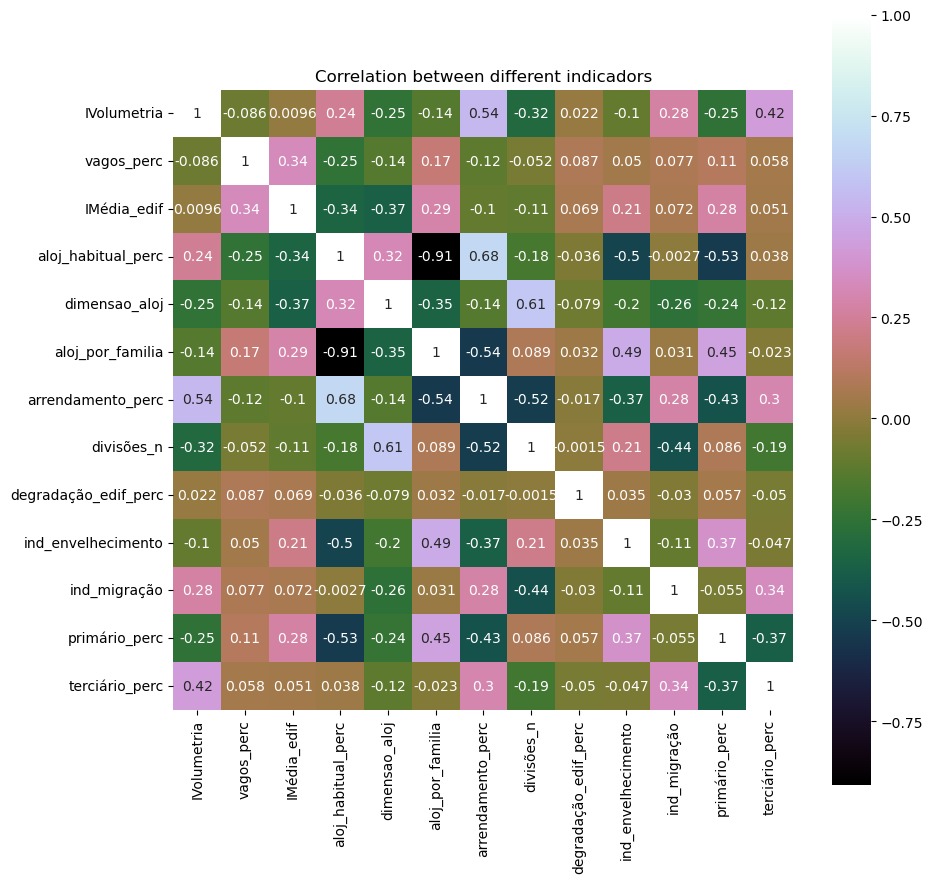

In [88]:
#another way to represent the correlation matrix of the 12 indicators
correlation = df_ind[indicators_list].corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation, square = True, annot = True, cmap='cubehelix')
plt.title('Correlation between different indicadors')

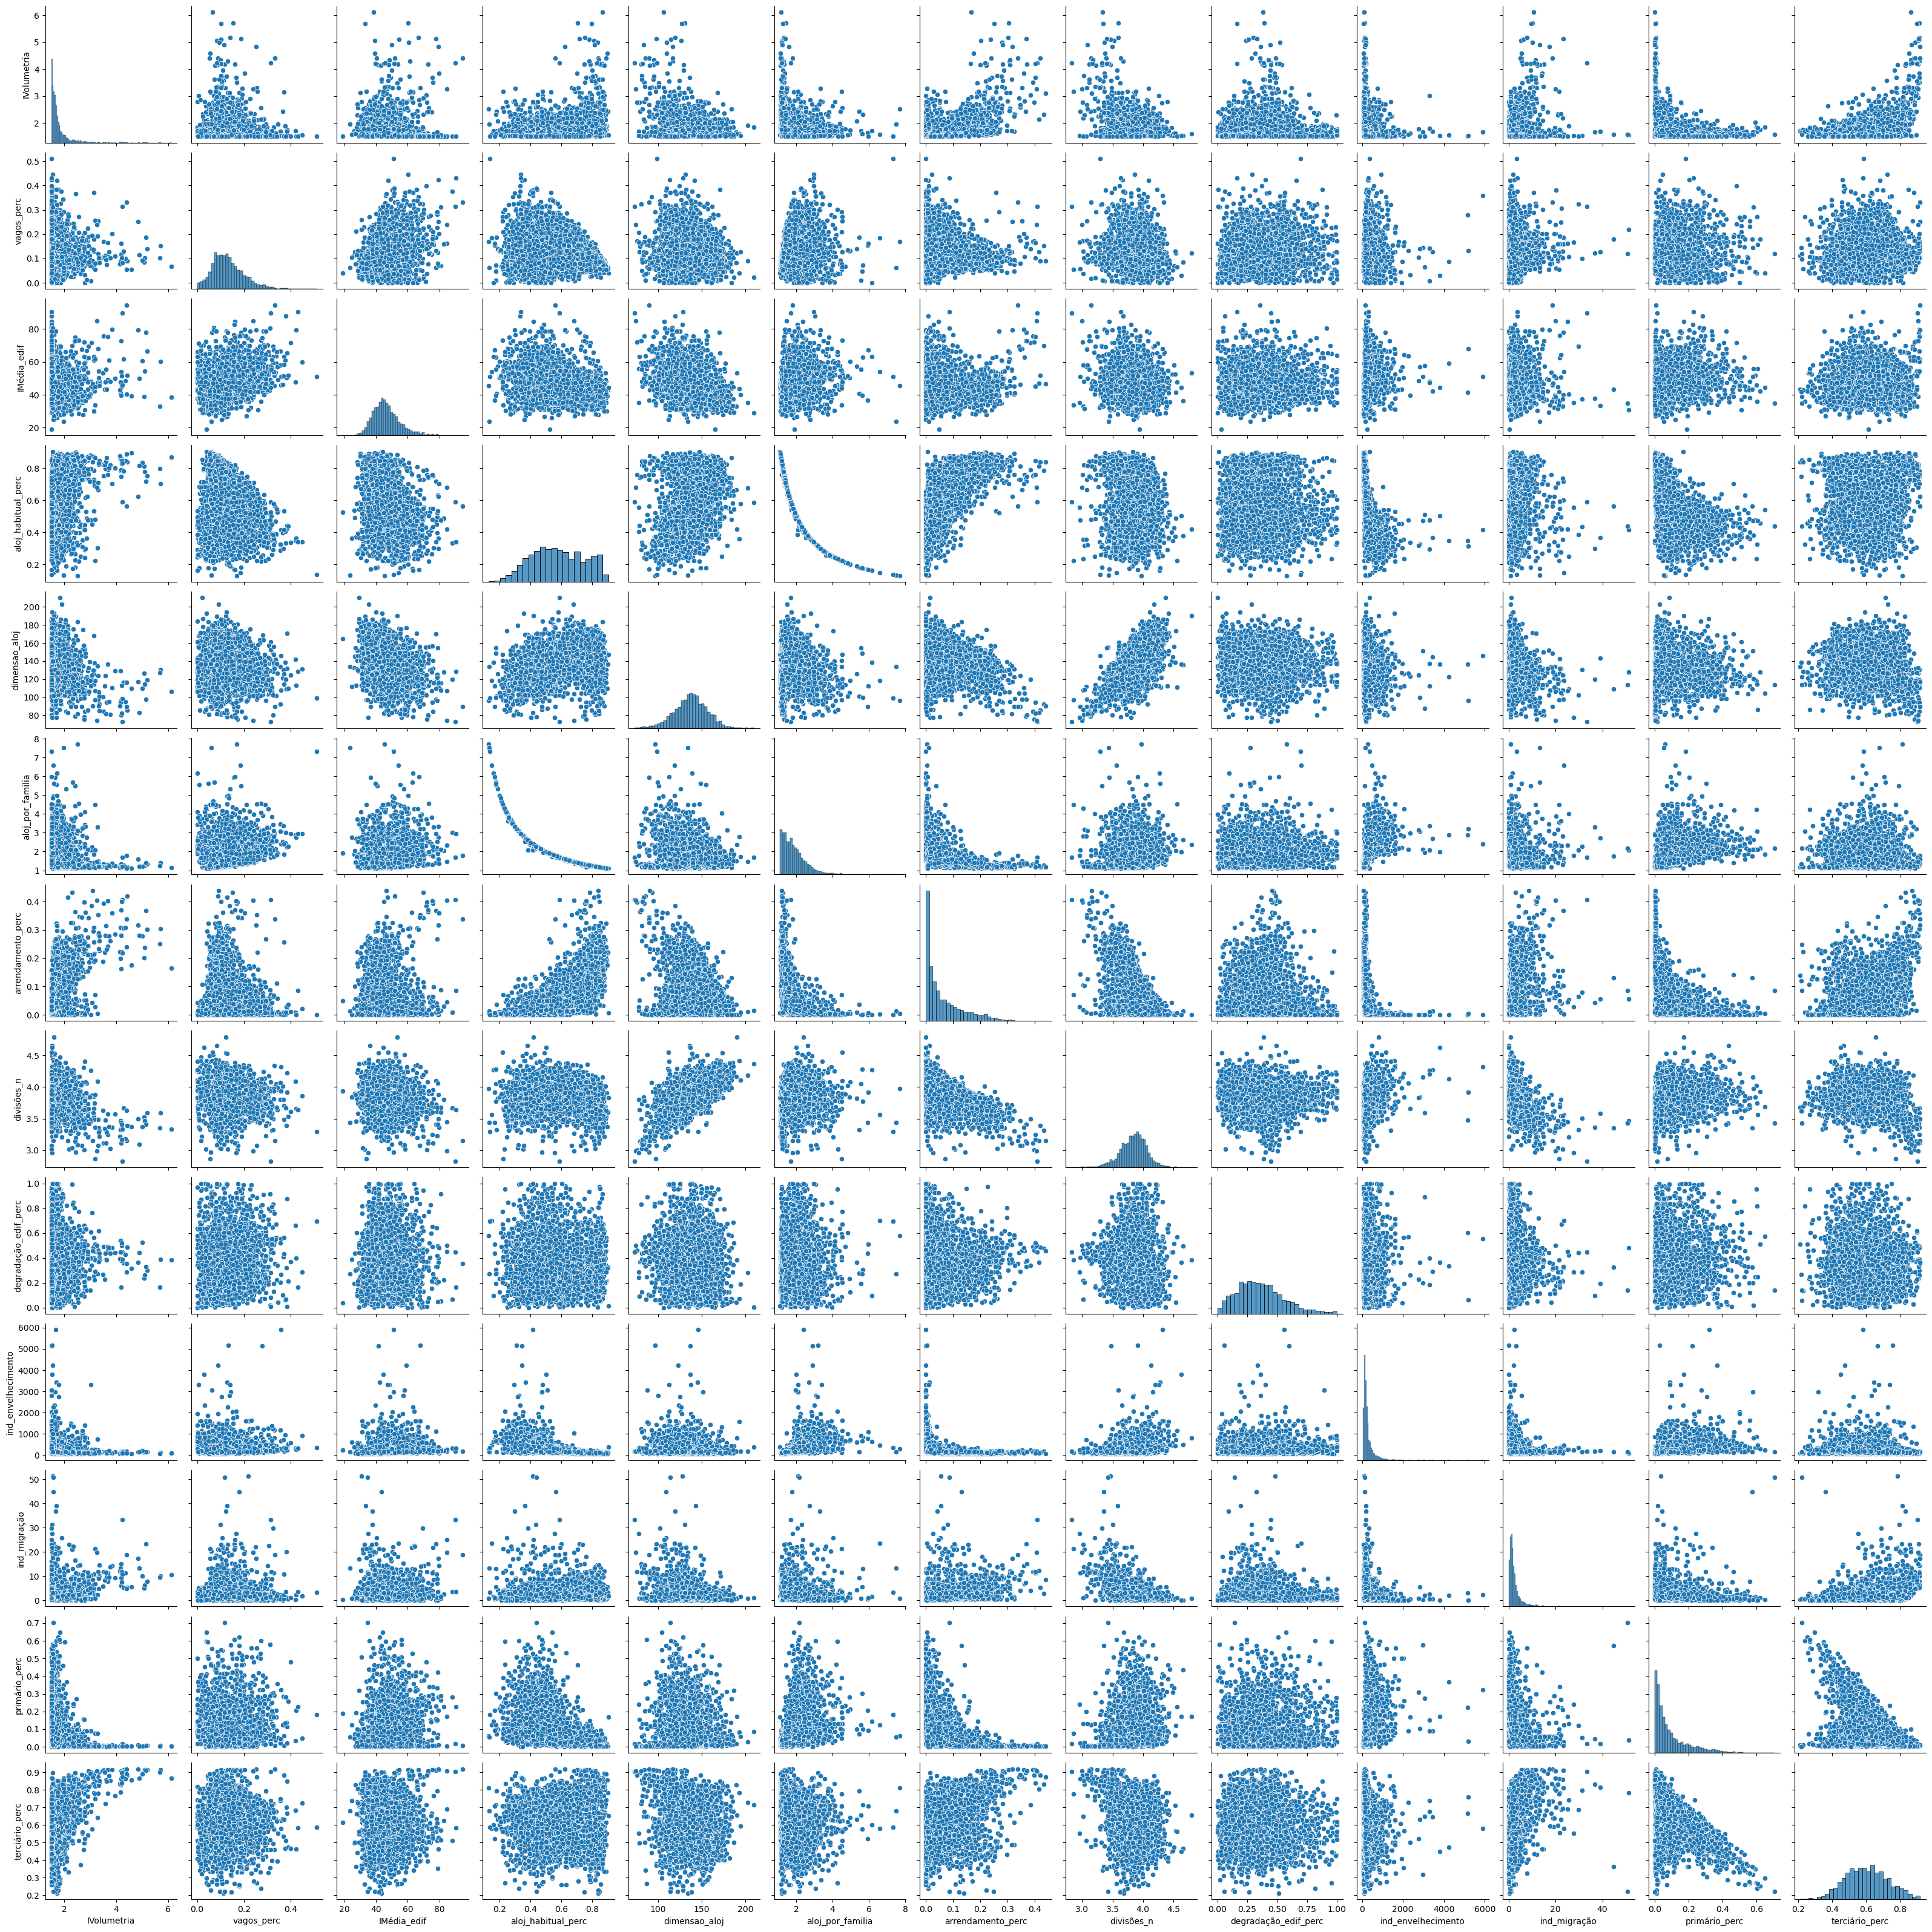

In [89]:
#another way to represent the correlation matrix of the 12 indicators
sns.pairplot(df_ind[indicators_list])

### Bartlett’s Test of Sphericity and KMO Test

Checks whether the correlation is present in the given data.  Before performing a factor analysis it is necessary to assess whether it is feasible, that is, whether or not we can find common factors in the data set.

There are two methods to verify this viability:

* <font color='slategrey'>Bartlett’s Test of Sphericity</font>

Compares the correlation matrix to the identity matrix. If the test is statistically insignificant, the application of the factor analysis is not recommended.

    The null hypothesis (H0) assumes that no correlation is present among the variables. ie., the correlation matrix is an     Identical matrix.

The idea is to reject this null hypothesis because the aim of factor analysis is explaining the common variance i.e. the variation due to correlation among the variables. If the p test statistic value is less than 0.05, we can decide that the correlation is not an Identical matrix i.e. correlation is present among the variables with a 95% confidence level.

* <font color='slategrey'>Kaiser-Meyer-Olkin Test (KMO)</font

Estimates the proportion of the variance among all observed variables
The KMO values range from 0 to 1. 

Values of less than 0.6 are considered inappropriate for the application of the analysis

  * For reference, Kaiser put the following values on the results:

      - 0.00 to 0.49 unacceptable
      - 0.50 to 0.59 miserable.
      - 0.60 to 0.69 mediocre.
      - 0.70 to 0.79 middling.
      - 0.80 to 0.89 meritorious.
      - 0.90 to 1.00 marvelous.

In [90]:
#Bartlett's Test Aplication of the 
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(df_ind[indicators_list])
chi_square_value, p_value

(np.float64(17630.023886024483), np.float64(0.0))

In [91]:
#KMO Aplication 
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model=calculate_kmo(df_ind[indicators_list])
kmo_model

np.float64(0.7161292186325702)

**Normalization**

In [92]:
df_ind.columns.tolist()

['NUTS2',
 'NUTS2 DSG',
 'NUTS3',
 'NUTS3 DSG',
 'MUNICIPIO',
 'MUNICIPIO DSG',
 'FREGUESIA',
 'FREGUESIA DSG',
 'IVolumetria',
 'vagos_perc',
 'IMédia_edif',
 'aloj_habitual_perc',
 'dimensao_aloj',
 'aloj_por_familia',
 'arrendamento_perc',
 'divisões_n',
 'degradação_edif_perc',
 'ind_envelhecimento',
 'ind_migração',
 'primário_perc',
 'terciário_perc']

In [93]:
# Create a DataFrame with the columns you want to normalize
df_to_normalize = df[['IVolumetria', 'vagos_perc', 'IMédia_edif',
                          'aloj_habitual_perc', 'dimensao_aloj', 'aloj_por_familia',
                          'arrendamento_perc', 'divisões_n', 'degradação_edif_perc',
                          'ind_envelhecimento', 'ind_migração',
                          'primário_perc', 'terciário_perc']]

# Perform the normalization
df_normalized = (df_to_normalize - df_to_normalize.mean()) / df_to_normalize.std()

# Add back the columns you didn't want to normalize
df_normalized[['NUTS2',
 'NUTS2 DSG',
 'NUTS3',
 'NUTS3 DSG',
 'MUNICIPIO',
 'MUNICIPIO DSG',
 'FREGUESIA',
 'FREGUESIA DSG']] = df[['NUTS2',
 'NUTS2 DSG',
 'NUTS3',
 'NUTS3 DSG',
 'MUNICIPIO',
 'MUNICIPIO DSG',
 'FREGUESIA',
 'FREGUESIA DSG']]

df_normalized


,IVolumetria,vagos_perc,IMédia_edif,aloj_habitual_perc,dimensao_aloj,aloj_por_familia,arrendamento_perc,divisões_n,degradação_edif_perc,ind_envelhecimento,...,primário_perc,terciário_perc,NUTS2,NUTS2 DSG,NUTS3,NUTS3 DSG,MUNICIPIO,MUNICIPIO DSG,FREGUESIA,FREGUESIA DSG
5,-0.336968,0.058104,0.655330,-0.247299,0.324468,-0.067975,-0.878081,0.097914,-1.355540,-0.032972,...,-0.324418,0.402953,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160101,Aboim das Choças
7,-0.204311,-0.322800,-1.367519,-0.067987,0.479618,-0.209009,-0.469833,-0.055348,0.343890,-0.224329,...,-0.585961,-0.876559,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160102,Aguiã
9,-0.328981,-1.105438,0.012797,-0.446915,0.413638,0.108886,-0.725979,0.094450,-0.504155,0.026504,...,0.173699,0.510907,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160104,Ázere
11,-0.513060,1.330878,0.626144,-1.999745,-0.452004,3.155638,-0.814249,-0.182810,1.131672,2.646014,...,0.194507,-1.745000,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160105,Cabana Maior
13,-0.351524,0.142011,2.314064,-0.594155,-0.933628,0.255228,-0.841718,-0.949760,2.419048,1.499970,...,0.350566,-0.353758,11.0,Norte,111,Alto Minho,1601.0,Arcos de Valdevez,160106,Cabreiro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13103,-0.628935,0.673167,-0.367874,0.873746,1.059251,-0.757335,-0.476653,0.226365,-1.428354,-0.576073,...,-0.126516,0.942337,18.0,Alentejo,187,Alentejo Central,713.0,Viana do Alentejo,071303,Aguiar
13106,-0.657104,-0.411339,1.401727,0.435483,-0.831657,-0.538717,1.219738,-1.190785,-0.754453,-0.429842,...,-0.047081,-0.578956,18.0,Alentejo,187,Alentejo Central,714.0,Vila Viçosa,071401,Bencatel
13109,-0.632600,-0.907962,0.833680,-0.174822,-0.977168,-0.126844,-0.211657,-0.853588,-1.479484,0.060078,...,0.676811,-0.637007,18.0,Alentejo,187,Alentejo Central,714.0,Vila Viçosa,071402,Ciladas
13111,-0.558200,0.181084,-0.219879,-0.338515,0.160218,0.010020,0.102574,-0.620962,-1.498536,-0.398060,...,-0.025277,-0.398263,18.0,Alentejo,187,Alentejo Central,714.0,Vila Viçosa,071404,Pardais


### Communalities

Proportion of the variance of each variable that is explained by the selected factors - are the sum of the squared loadings for each variable.

After extraction, the communities range between 0 and 1,

Values close to 0 when the common factors explain no variance of the variable
Values close to 1 when they explain all of its variance - represents more variance

In [94]:
#to calculate the Communalities 
fa = FactorAnalyzer(method = 'principal', rotation= 'varimax')
fa.fit(df_normalized[indicators_list])

# Get communalities
communalities = fa.get_communalities()

# Create a DataFrame for better visualization
communalities_df = pd.DataFrame({
    'Variable': indicators_list,
    'Communality': communalities
})

print(communalities_df)

                Variable  Communality
0            IVolumetria     0.543896
1             vagos_perc     0.189765
2            IMédia_edif     0.414000
3     aloj_habitual_perc     0.902908
4          dimensao_aloj     0.730855
5       aloj_por_familia     0.811961
6      arrendamento_perc     0.793440
7             divisões_n     0.742830
8   degradação_edif_perc     0.167044
9     ind_envelhecimento     0.465322
10          ind_migração     0.429469
11         primário_perc     0.585769
12        terciário_perc     0.709077


c:\Users\paulo\.conda\envs\statsPythonR\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## Determining the number of factors

### Eingenvalues

The eigenvalue is a good criterion for determining the number of factors. Generally, an eigenvalue greater than 1 will be considered as selection criteria for the feature.


Scree plot the eigenvalues of our initial solution (A factor with an eigenvalue of 1 accounts for at least the variance of a single feature)

### Scree plot
The graphical approach is based on the visual representation of factors' eigenvalues also called scree plot. This scree plot helps us to determine the number of factors where the curve makes an elbow.

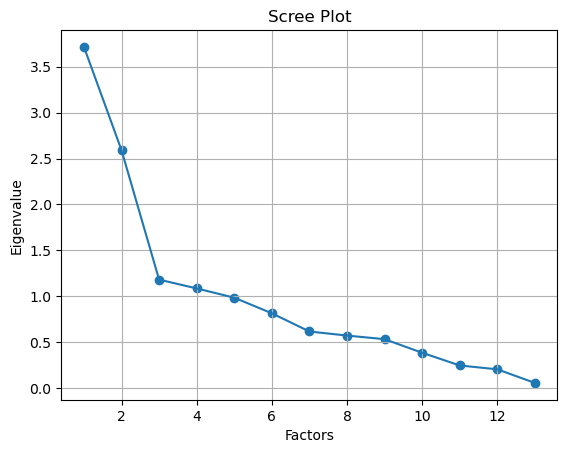

In [95]:
#Extract eigenvalues and create the Scree Plot
eigen_values, vectors = fa.get_eigenvalues()
plt.scatter(range(1,df_normalized[indicators_list].shape[1]+1),eigen_values)
plt.plot(range(1,df_normalized[indicators_list].shape[1]+1),eigen_values)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

### Explained variance

The total <font color='slategrey'>variance explained</font> must be conveniently greater than 70%

In [96]:
#to calculate the explained variances
tot = sum(eigen_values)
var_exp = [(i / tot)*100 for i in sorted(eigen_values,reverse=True)]

# Calculate cumulative explained variance
cum_var_exp = [sum(var_exp[:i+1]) for i in range(len(var_exp))]

# Create a DataFrame for better visualization
explained_var_df = pd.DataFrame({
    'Component': [f'Component {i+1}' for i in range(len(var_exp))],
    'Explained Variance': var_exp,
    'Cumulative Explained Variance': cum_var_exp
})

print(explained_var_df)


       Component  Explained Variance  Cumulative Explained Variance
0    Component 1           28.569398                      28.569398
1    Component 2           19.924056                      48.493454
2    Component 3            9.093750                      57.587204
3    Component 4            8.356952                      65.944156
4    Component 5            7.581920                      73.526077
5    Component 6            6.277193                      79.803270
6    Component 7            4.753746                      84.557016
7    Component 8            4.412344                      88.969360
8    Component 9            4.110882                      93.080243
9   Component 10            2.973562                      96.053805
10  Component 11            1.909023                      97.962828
11  Component 12            1.588391                      99.551219
12  Component 13            0.448781                     100.000000


In [98]:
var_exp

[np.float64(28.569397921950856),
 np.float64(19.924055785579633),
 np.float64(9.093750486973159),
 np.float64(8.356952193100293),
 np.float64(7.581920493922728),
 np.float64(6.277193162772346),
 np.float64(4.7537459841811875),
 np.float64(4.412344255520384),
 np.float64(4.110882491218667),
 np.float64(2.973562121386993),
 np.float64(1.9090230096164673),
 np.float64(1.5883907849351442),
 np.float64(0.44878130884215894)]

C:\Users\paulo\AppData\Local\Temp\ipykernel_4228\1279831808.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


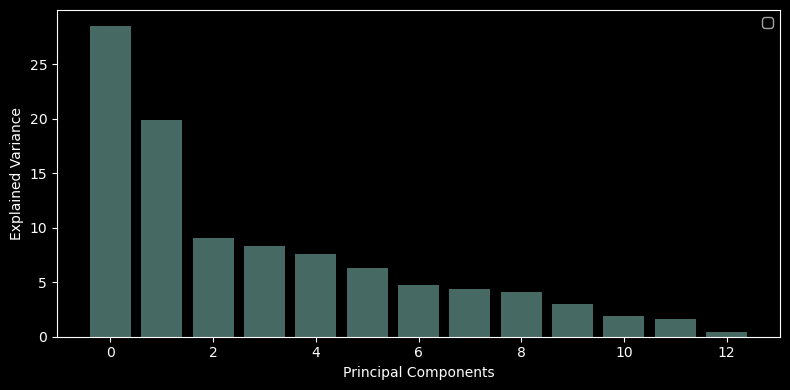

In [99]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(8, 4))
    plt.bar(range(13), var_exp, alpha=0.5, align='center')
    plt.ylabel('Explained Variance')
    plt.xlabel('Principal Components')
    plt.legend(loc='best')
    plt.tight_layout()

## Interpreting the Loadings of the factors

Loadings indicate how much a factor explains a variable and are cucial to classify the factors, since they indicate the correlation between each of the initial variables and the factors created The loading score will range from -1 to 1. Values close to -1 or 1 indicate that the factor has an influence on these variables. Values close to 0 indicates that the factor has a lower influencer on the variable.

In [100]:
#factor extraction - no rotation
fa = FactorAnalyzer(n_factors = 5, rotation=None, method = 'principal')
fa.fit(df_normalized[indicators_list])

# Get factor loadings
loadings = fa.loadings_ # The underscore is a naming convention to help differentiate between parameters that are set during initialization and attributes that are learned from the data

# Create a DataFrame for better visualization
loadings_df = pd.DataFrame(loadings, columns=[f'Factor {i+1}' for i in range(5)], index=indicators_list)

print(loadings_df)

                      Factor 1  Factor 2  Factor 3  Factor 4  Factor 5
IVolumetria          -0.479954  0.495989  0.259875 -0.060689  0.317165
vagos_perc            0.258535  0.281343 -0.209215  0.735474 -0.278232
IMédia_edif           0.372460  0.476122 -0.220415  0.328683 -0.094187
aloj_habitual_perc   -0.882609 -0.272986 -0.222232 -0.001280  0.009203
dimensao_aloj        -0.171030 -0.807930  0.221027  0.259239 -0.042599
aloj_por_familia      0.797879  0.331687  0.255603 -0.089465  0.041606
arrendamento_perc    -0.818913  0.327217 -0.125503 -0.070494  0.062674
divisões_n            0.370348 -0.706287  0.326849  0.237774  0.149347
degradação_edif_perc  0.076090  0.074261 -0.394638  0.300071  0.796943
ind_envelhecimento    0.618237  0.130513  0.257044 -0.166986  0.280631
ind_migração         -0.229968  0.597517  0.139849 -0.026117 -0.212101
primário_perc         0.690923  0.105420 -0.311900 -0.283719 -0.044238
terciário_perc       -0.327407  0.452092  0.630472  0.312961  0.089962


c:\Users\paulo\.conda\envs\statsPythonR\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


**Rotation**:
is a process that allows analysts to make a PCA/FA solution more interpretable.  Any rotation has a goal.  Orthogonal rotations require that factor should not be correlated. The goal of orthogonal rotation is generalizability and simplicity.  In contrast, oblique rotations allow for correlated factors and their goal is to produce the best fit. (Rotation Techniques: Varimax, Quartimax, Oblimax, Equimax - https://www.datasklr.com/principal-component-analysis-and-factor-analysis/factor-analysis)

In [102]:
# Factor extraction with Varimax rotation
fa_rot = FactorAnalyzer(n_factors=5, rotation='varimax', method='principal')
fa_rot.fit(df_normalized[indicators_list])

# Get factor loadings
loadings_rot = fa_rot.loadings_  # The underscore is a naming convention to help differentiate between parameters that are set during initialization and attributes that are learned from the data

# Create a DataFrame for better visualization
loadings_rot_df = pd.DataFrame(loadings_rot, columns=[f'Factor {i+1}' for i in range(5)], index=indicators_list)

#print(loadings_rot_df)

###------------

# Function to highlight different weights
def highlight_weights(val):
    color = 'red' if abs(val) > 0.7 else ('orange' if abs(val) > 0.5 else 'black')
    return f'color: {color}'

# Apply the styling
styled_df = loadings_rot_df.style.map(highlight_weights)

# To display in Jupyter Notebook
styled_df


c:\Users\paulo\.conda\envs\statsPythonR\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
IVolumetria,-0.124837,0.411411,0.623074,-0.204954,0.181940
vagos_perc,0.032551,-0.012501,0.026318,0.897468,0.027242
IMédia_edif,0.286963,0.276720,-0.041696,0.597698,0.114024
aloj_habitual_perc,-0.907584,0.012259,0.081315,-0.262984,0.057984
dimensao_aloj,-0.337184,-0.811280,-0.005974,-0.123902,-0.112335
aloj_por_familia,0.888117,0.072771,-0.018582,0.158762,-0.045803
arrendamento_perc,-0.638615,0.489222,0.347573,-0.164104,0.086215
divisões_n,0.228749,-0.871897,-0.066115,-0.061802,0.030828
degradação_edif_perc,0.019405,-0.010738,-0.015349,0.107158,0.938080
ind_envelhecimento,0.736493,-0.051411,0.005080,-0.096359,0.132604


## Extraction of the new factor values (scores) 

Factor values can be estimated as linear combinations of the original variables.
The factors are expressed as standardized values of mean 0 and standard deviation 1 (z-scores)  

In [103]:
#returns the scores for the selected row
scores = fa.transform(df_normalized[indicators_list])
scores

c:\Users\paulo\.conda\envs\statsPythonR\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[ 0.24525589, -0.2486288 ,  0.69781997,  0.26069325, -1.20309217],
       [-0.11913903, -0.82505529, -0.17263384, -0.42961971,  0.34850009],
       [ 0.23394384, -0.30417399,  0.7990359 , -0.60748718, -0.18596236],
       ...,
       [ 0.28788243,  0.31203069, -0.54192665, -1.49991175, -1.39164223],
       [-0.01808353, -0.07370114,  0.01675052, -0.4803392 , -1.68445227],
       [-0.7593439 ,  0.36064851, -0.0535512 ,  0.42209267, -0.9709423 ]],
      shape=(2882, 5))

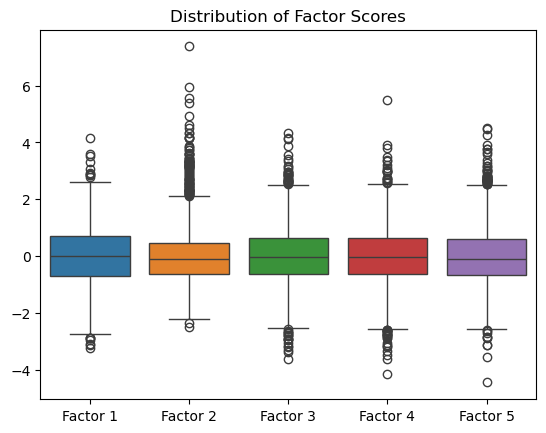

In [104]:
# Convert scores to DataFrame for easier plotting
scores_df = pd.DataFrame(scores, columns=[f'Factor {i+1}' for i in range(scores.shape[1])])

sns.boxplot(data=scores_df)
plt.title('Distribution of Factor Scores')
plt.show()


In [105]:
#to set the scores as columns for each observation in the  datafaframe
def set_scores_factors(dataframe, scores):
  for i in list(range(len(scores[0]))):
    serie_factor = []
    for e in scores:
      serie_factor.append(e[i])
    dataframe["factor_{}".format(i+1)] = pd.Series(serie_factor,dataframe.index) 
  return dataframe

df_normalized = set_scores_factors(df_normalized, scores)
df_normalized

,IVolumetria,vagos_perc,IMédia_edif,aloj_habitual_perc,dimensao_aloj,aloj_por_familia,arrendamento_perc,divisões_n,degradação_edif_perc,ind_envelhecimento,...,NUTS3 DSG,MUNICIPIO,MUNICIPIO DSG,FREGUESIA,FREGUESIA DSG,factor_1,factor_2,factor_3,factor_4,factor_5
5,-0.336968,0.058104,0.655330,-0.247299,0.324468,-0.067975,-0.878081,0.097914,-1.355540,-0.032972,...,Alto Minho,1601.0,Arcos de Valdevez,160101,Aboim das Choças,0.245256,-0.248629,0.697820,0.260693,-1.203092
7,-0.204311,-0.322800,-1.367519,-0.067987,0.479618,-0.209009,-0.469833,-0.055348,0.343890,-0.224329,...,Alto Minho,1601.0,Arcos de Valdevez,160102,Aguiã,-0.119139,-0.825055,-0.172634,-0.429620,0.348500
9,-0.328981,-1.105438,0.012797,-0.446915,0.413638,0.108886,-0.725979,0.094450,-0.504155,0.026504,...,Alto Minho,1601.0,Arcos de Valdevez,160104,Ázere,0.233944,-0.304174,0.799036,-0.607487,-0.185962
11,-0.513060,1.330878,0.626144,-1.999745,-0.452004,3.155638,-0.814249,-0.182810,1.131672,2.646014,...,Alto Minho,1601.0,Arcos de Valdevez,160105,Cabana Maior,2.228442,0.668674,-0.273130,0.125693,1.014989
13,-0.351524,0.142011,2.314064,-0.594155,-0.933628,0.255228,-0.841718,-0.949760,2.419048,1.499970,...,Alto Minho,1601.0,Arcos de Valdevez,160106,Cabreiro,1.048061,0.880063,-1.544345,0.677354,1.930569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13103,-0.628935,0.673167,-0.367874,0.873746,1.059251,-0.757335,-0.476653,0.226365,-1.428354,-0.576073,...,Alentejo Central,713.0,Viana do Alentejo,071303,Aguiar,-0.402200,-0.778300,0.625039,0.784370,-1.546654
13106,-0.657104,-0.411339,1.401727,0.435483,-0.831657,-0.538717,1.219738,-1.190785,-0.754453,-0.429842,...,Alentejo Central,714.0,Vila Viçosa,071401,Bencatel,-0.404567,0.519665,-1.306622,-0.604297,-1.056530
13109,-0.632600,-0.907962,0.833680,-0.174822,-0.977168,-0.126844,-0.211657,-0.853588,-1.479484,0.060078,...,Alentejo Central,714.0,Vila Viçosa,071402,Ciladas,0.287882,0.312031,-0.541927,-1.499912,-1.391642
13111,-0.558200,0.181084,-0.219879,-0.338515,0.160218,0.010020,0.102574,-0.620962,-1.498536,-0.398060,...,Alentejo Central,714.0,Vila Viçosa,071404,Pardais,-0.018084,-0.073701,0.016751,-0.480339,-1.684452


In [106]:
# creation of an array of factor scores
factor_list = ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
df_normalized[factor_list]

,factor_1,factor_2,factor_3,factor_4,factor_5
5,0.245256,-0.248629,0.697820,0.260693,-1.203092
7,-0.119139,-0.825055,-0.172634,-0.429620,0.348500
9,0.233944,-0.304174,0.799036,-0.607487,-0.185962
11,2.228442,0.668674,-0.273130,0.125693,1.014989
13,1.048061,0.880063,-1.544345,0.677354,1.930569
...,...,...,...,...,...
13103,-0.402200,-0.778300,0.625039,0.784370,-1.546654
13106,-0.404567,0.519665,-1.306622,-0.604297,-1.056530
13109,0.287882,0.312031,-0.541927,-1.499912,-1.391642
13111,-0.018084,-0.073701,0.016751,-0.480339,-1.684452


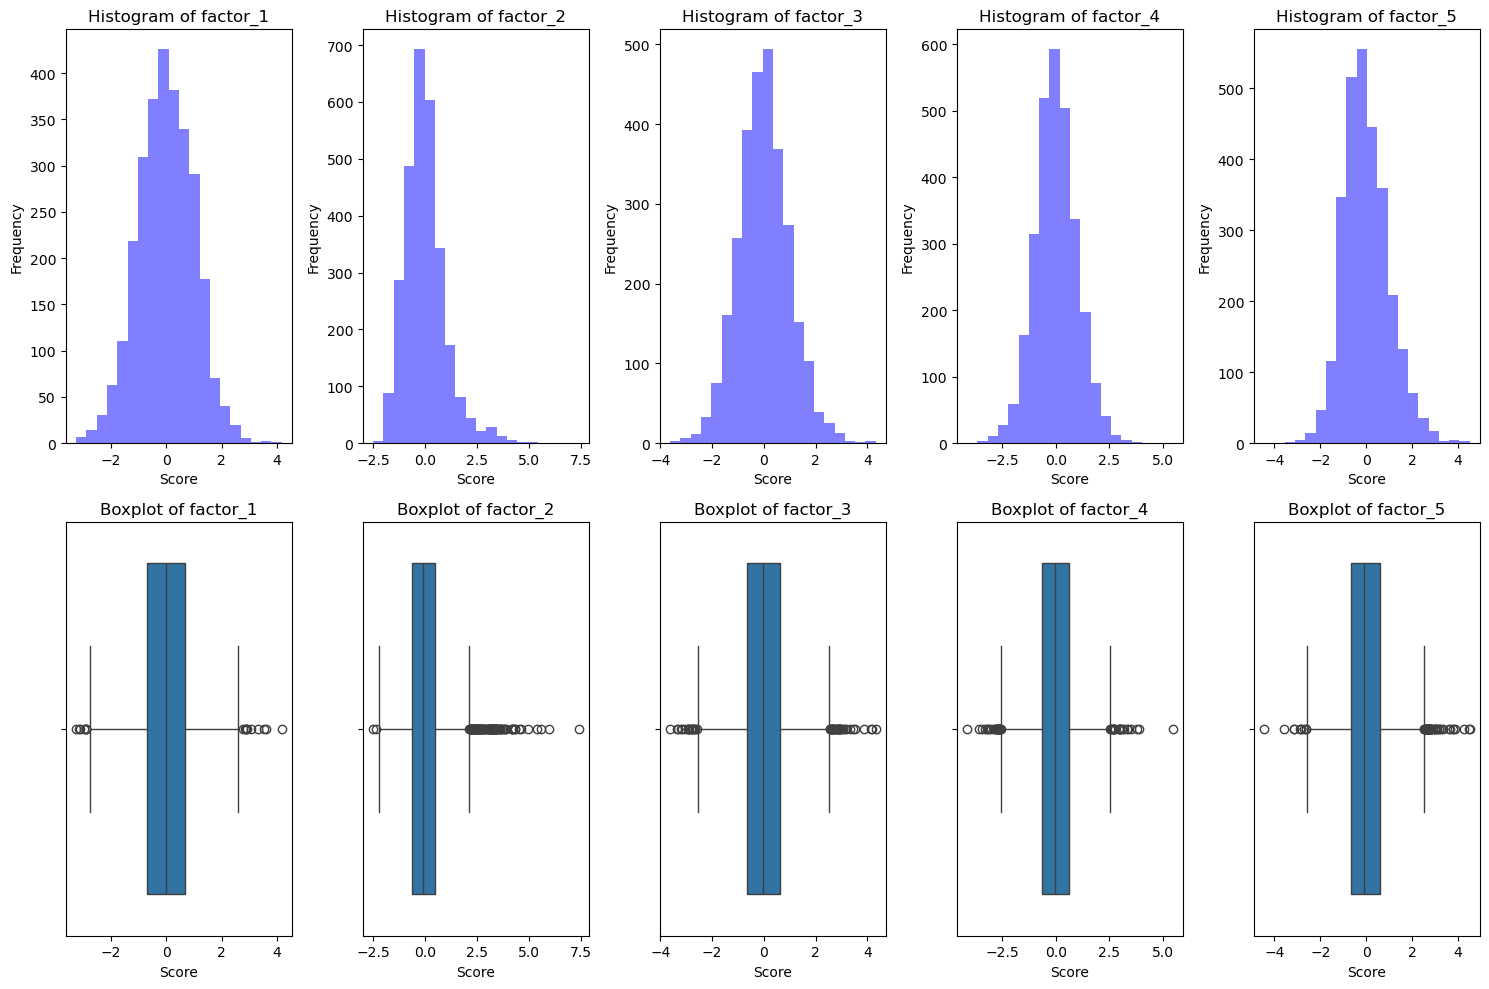

In [107]:
# Create subplots: 2 rows and as many columns as there are factors
fig, axes = plt.subplots(2, len(factor_list), figsize=(15, 10))

# Loop through each factor to create the plots
for i, factor in enumerate(factor_list):
    # Histogram
    axes[0, i].hist(df_normalized[factor], bins=20, alpha=0.5, color='blue')
    axes[0, i].set_title(f'Histogram of {factor}')
    axes[0, i].set_xlabel('Score')
    axes[0, i].set_ylabel('Frequency')
    
    # Boxplot
    sns.boxplot(x=df_normalized[factor], ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot of {factor}')
    axes[1, i].set_xlabel('Score')

plt.tight_layout()
plt.show()


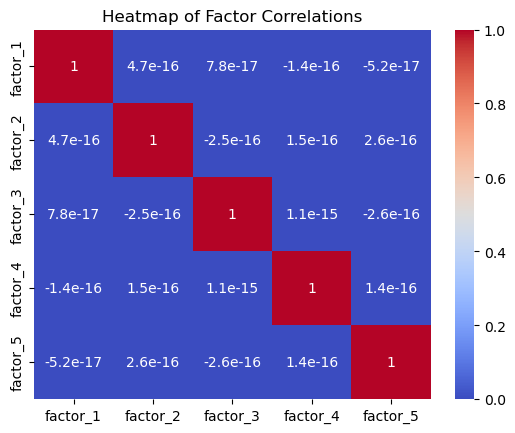

In [108]:
#correlation between factor
correlation_matrix = df_normalized[factor_list].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap of Factor Correlations')
plt.show()


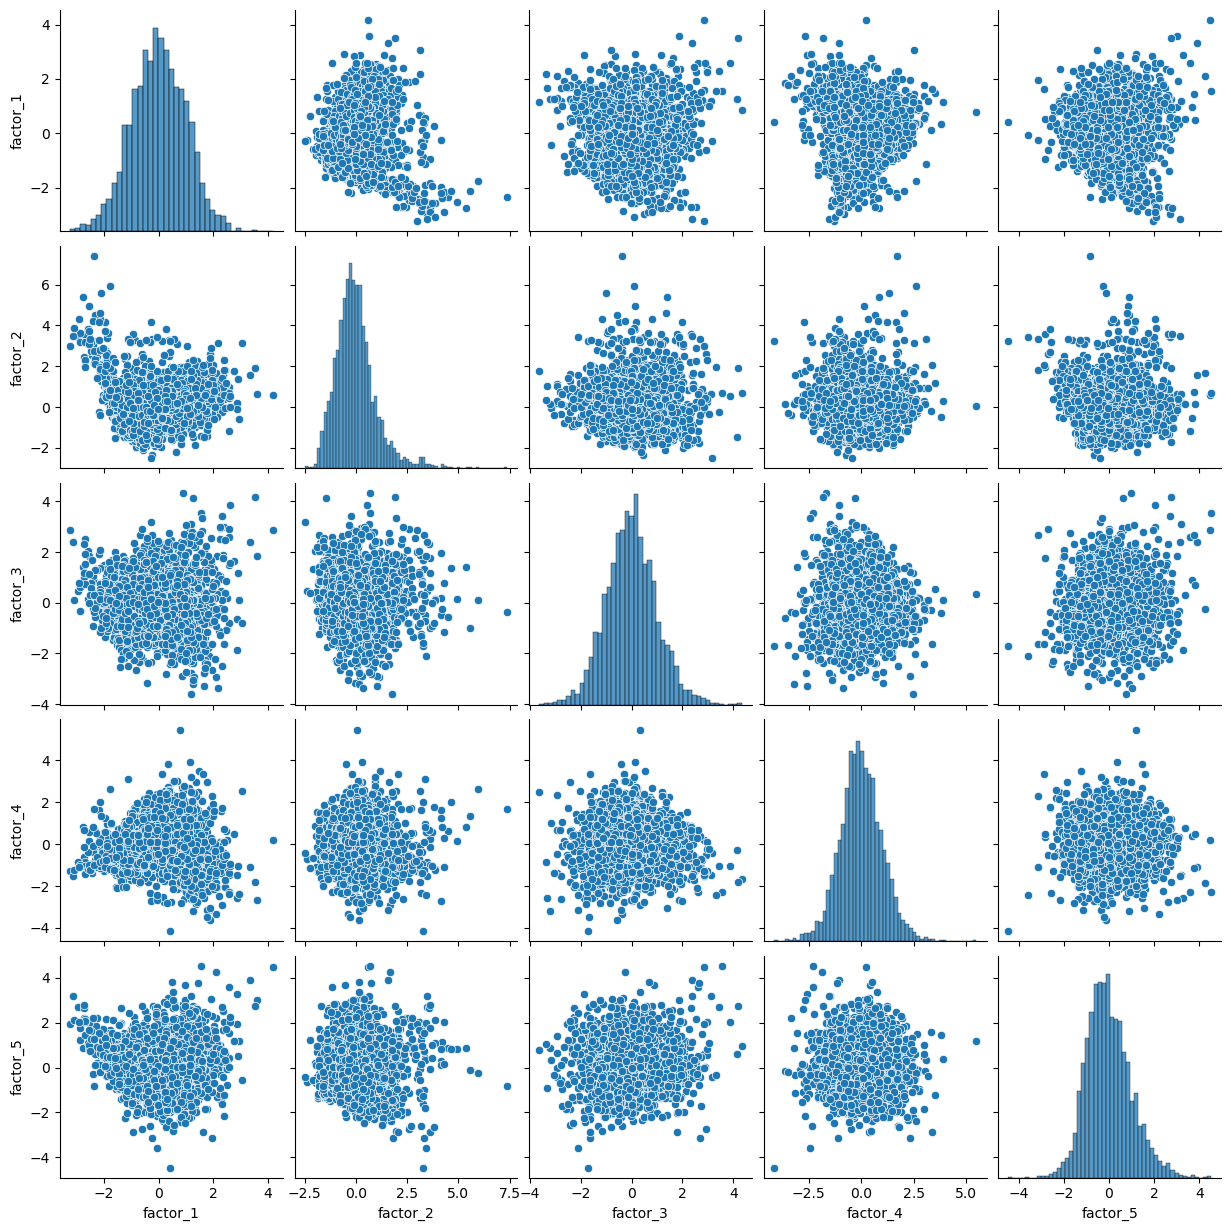

In [109]:
g = sns.pairplot(df_normalized[factor_list])

# **2. Cluster Analysis**

<font color='slategrey'>Cluster analysis</font> is a multivariate statistical method to organise items into groups, based on how closely associated they are.
The idea is to find similar groups of subjects, where “similarity” between each pair of subjects means some global measure over the whole set of characteristics.

## K-Means 

In [118]:
# Create a KMeans instance with the number of clusters you want (e.g., 3)
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit the model
kmeans.fit(df_normalized[factor_list])

# Get the cluster assignments for each data point
df_normalized['cluster'] = kmeans.labels_

# Get the coordinates of the cluster centers
cluster_centers = kmeans.cluster_centers_

# Now, df_BGRIzsc has an additional column named 'cluster' containing the cluster assignments.
df_normalized['cluster']

c:\Users\paulo\.conda\envs\statsPythonR\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


5        2
7        2
9        2
11       0
13       1
        ..
13103    2
13106    2
13109    0
13111    2
13113    2
Name: cluster, Length: 2882, dtype: int32

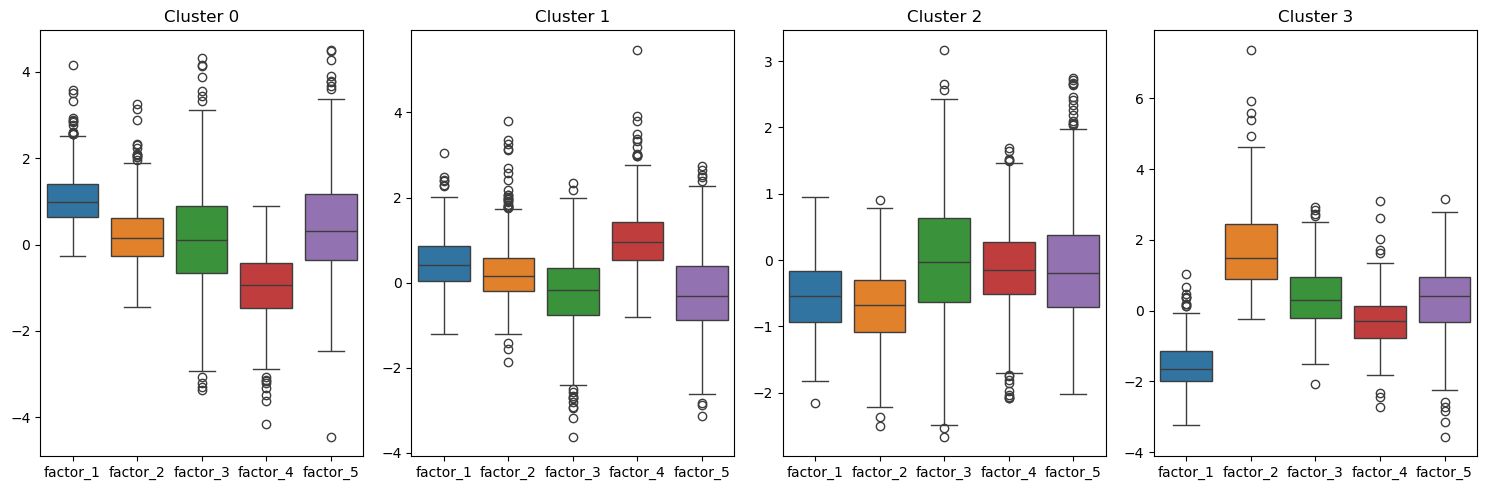

In [120]:
# Create a figure and a grid of subplots
fig, ax = plt.subplots(1, 4, figsize=(15, 5))

# Loop over each cluster
for cluster_id in range(4):
    # Filter data by cluster
    cluster_data = df_normalized[df_normalized['cluster'] == cluster_id]
    
    # Create a boxplot for the filtered data
    sns.boxplot(data=cluster_data[['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']], ax=ax[cluster_id])
    
    # Set the title for this subplot
    ax[cluster_id].set_title(f'Cluster {cluster_id}')

plt.tight_layout()
plt.show()


## Hierarchical Clustering

The scipy library contains tools for doing hierarchical clustering and building dendrograms
https://www.analyticsvidhya.com/blog/2019/05/beginners-guide-hierarchical-clustering/

In [121]:
df_normalized

,IVolumetria,vagos_perc,IMédia_edif,aloj_habitual_perc,dimensao_aloj,aloj_por_familia,arrendamento_perc,divisões_n,degradação_edif_perc,ind_envelhecimento,...,MUNICIPIO,MUNICIPIO DSG,FREGUESIA,FREGUESIA DSG,factor_1,factor_2,factor_3,factor_4,factor_5,cluster
5,-0.336968,0.058104,0.655330,-0.247299,0.324468,-0.067975,-0.878081,0.097914,-1.355540,-0.032972,...,1601.0,Arcos de Valdevez,160101,Aboim das Choças,0.245256,-0.248629,0.697820,0.260693,-1.203092,2
7,-0.204311,-0.322800,-1.367519,-0.067987,0.479618,-0.209009,-0.469833,-0.055348,0.343890,-0.224329,...,1601.0,Arcos de Valdevez,160102,Aguiã,-0.119139,-0.825055,-0.172634,-0.429620,0.348500,2
9,-0.328981,-1.105438,0.012797,-0.446915,0.413638,0.108886,-0.725979,0.094450,-0.504155,0.026504,...,1601.0,Arcos de Valdevez,160104,Ázere,0.233944,-0.304174,0.799036,-0.607487,-0.185962,2
11,-0.513060,1.330878,0.626144,-1.999745,-0.452004,3.155638,-0.814249,-0.182810,1.131672,2.646014,...,1601.0,Arcos de Valdevez,160105,Cabana Maior,2.228442,0.668674,-0.273130,0.125693,1.014989,0
13,-0.351524,0.142011,2.314064,-0.594155,-0.933628,0.255228,-0.841718,-0.949760,2.419048,1.499970,...,1601.0,Arcos de Valdevez,160106,Cabreiro,1.048061,0.880063,-1.544345,0.677354,1.930569,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13103,-0.628935,0.673167,-0.367874,0.873746,1.059251,-0.757335,-0.476653,0.226365,-1.428354,-0.576073,...,713.0,Viana do Alentejo,071303,Aguiar,-0.402200,-0.778300,0.625039,0.784370,-1.546654,2
13106,-0.657104,-0.411339,1.401727,0.435483,-0.831657,-0.538717,1.219738,-1.190785,-0.754453,-0.429842,...,714.0,Vila Viçosa,071401,Bencatel,-0.404567,0.519665,-1.306622,-0.604297,-1.056530,2
13109,-0.632600,-0.907962,0.833680,-0.174822,-0.977168,-0.126844,-0.211657,-0.853588,-1.479484,0.060078,...,714.0,Vila Viçosa,071402,Ciladas,0.287882,0.312031,-0.541927,-1.499912,-1.391642,0
13111,-0.558200,0.181084,-0.219879,-0.338515,0.160218,0.010020,0.102574,-0.620962,-1.498536,-0.398060,...,714.0,Vila Viçosa,071404,Pardais,-0.018084,-0.073701,0.016751,-0.480339,-1.684452,2


**Dendrogram** 

The following code is for generating a dendrogram using hierarchical clustering, specifically using the "ward" method. 
The dendrogram is a tree-like diagram that shows the arrangement of the clusters formed by the hierarchical clustering algorithm. 

*How to Interpret the Dendrogram:*
- The *x-axis* contains the individual data points (or clusters of data points as the algorithm proceeds).

- The y-axis represents the Euclidean distances between these points or clusters.

- Each *leaf* at the bottom of the dendrogram represents one data point, and as we move up the tree, leaves that are close to each other merge into branches, indicating that they belong to the same cluster.

- The *height* at which two branches merge represents the distance at which these clusters were combined. This is useful for determining the optimal number of clusters: we typically look for the longest vertical line that is not crossed by any extended horizontal lines (or with very few crossings), and we draw a horizontal line through it. The number of vertical lines it crosses gives you the optimal number of clusters.

*To represent the outputs or results, we can:*

- Use the dendrogram to decide on an optimal number of clusters.

- Use this number to run a final hierarchical clustering algorithm that assigns each data point to a cluster.

- Analyze these clusters further, perhaps by examining the mean or distribution of various features within each cluster.

- Optionally, we can visualize these clusters using scatter plots, box plots, or other types of graphs to understand their characteristics.

Report these findings as your final output or result

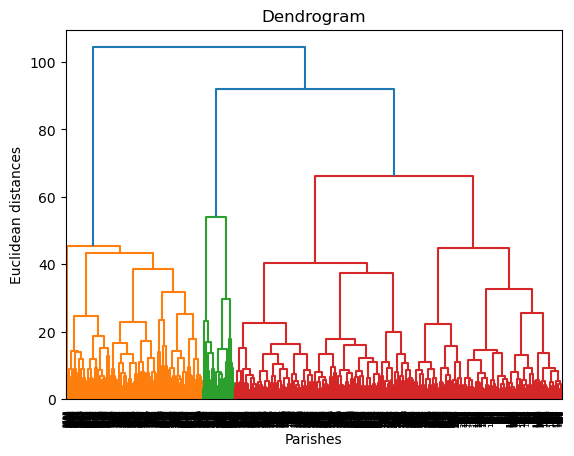

In [129]:
#dendogram using the 12 indicators 
dendrogram = sch.dendrogram(sch.linkage(df_normalized[indicators_list], method  = "ward"))
plt.title('Dendrogram')
plt.xlabel('Parishes')
plt.ylabel('Euclidean distances')
plt.show()

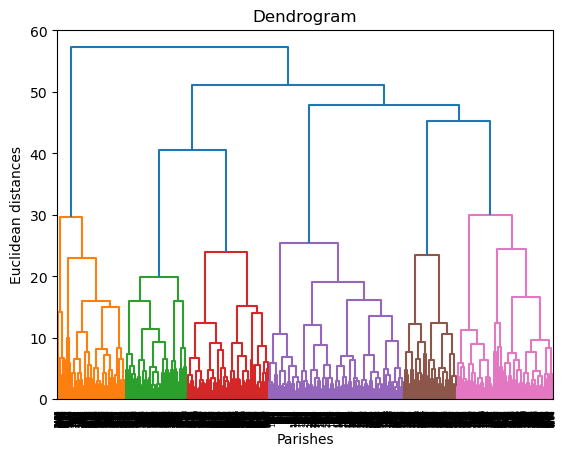

In [123]:
#dendogram using the 5 factors indicators
dendrogram = sch.dendrogram(sch.linkage(df_normalized[factor_list], method  = "ward"))
plt.title('Dendrogram')
plt.xlabel('Parishes')
plt.ylabel('Euclidean distances')
plt.show()

**Scatter plots** are useful for visualizing how clusters are distributed in a two-dimensional feature space. We can create scatter plots for different pairs of features to get a sense of how the clusters are separated.

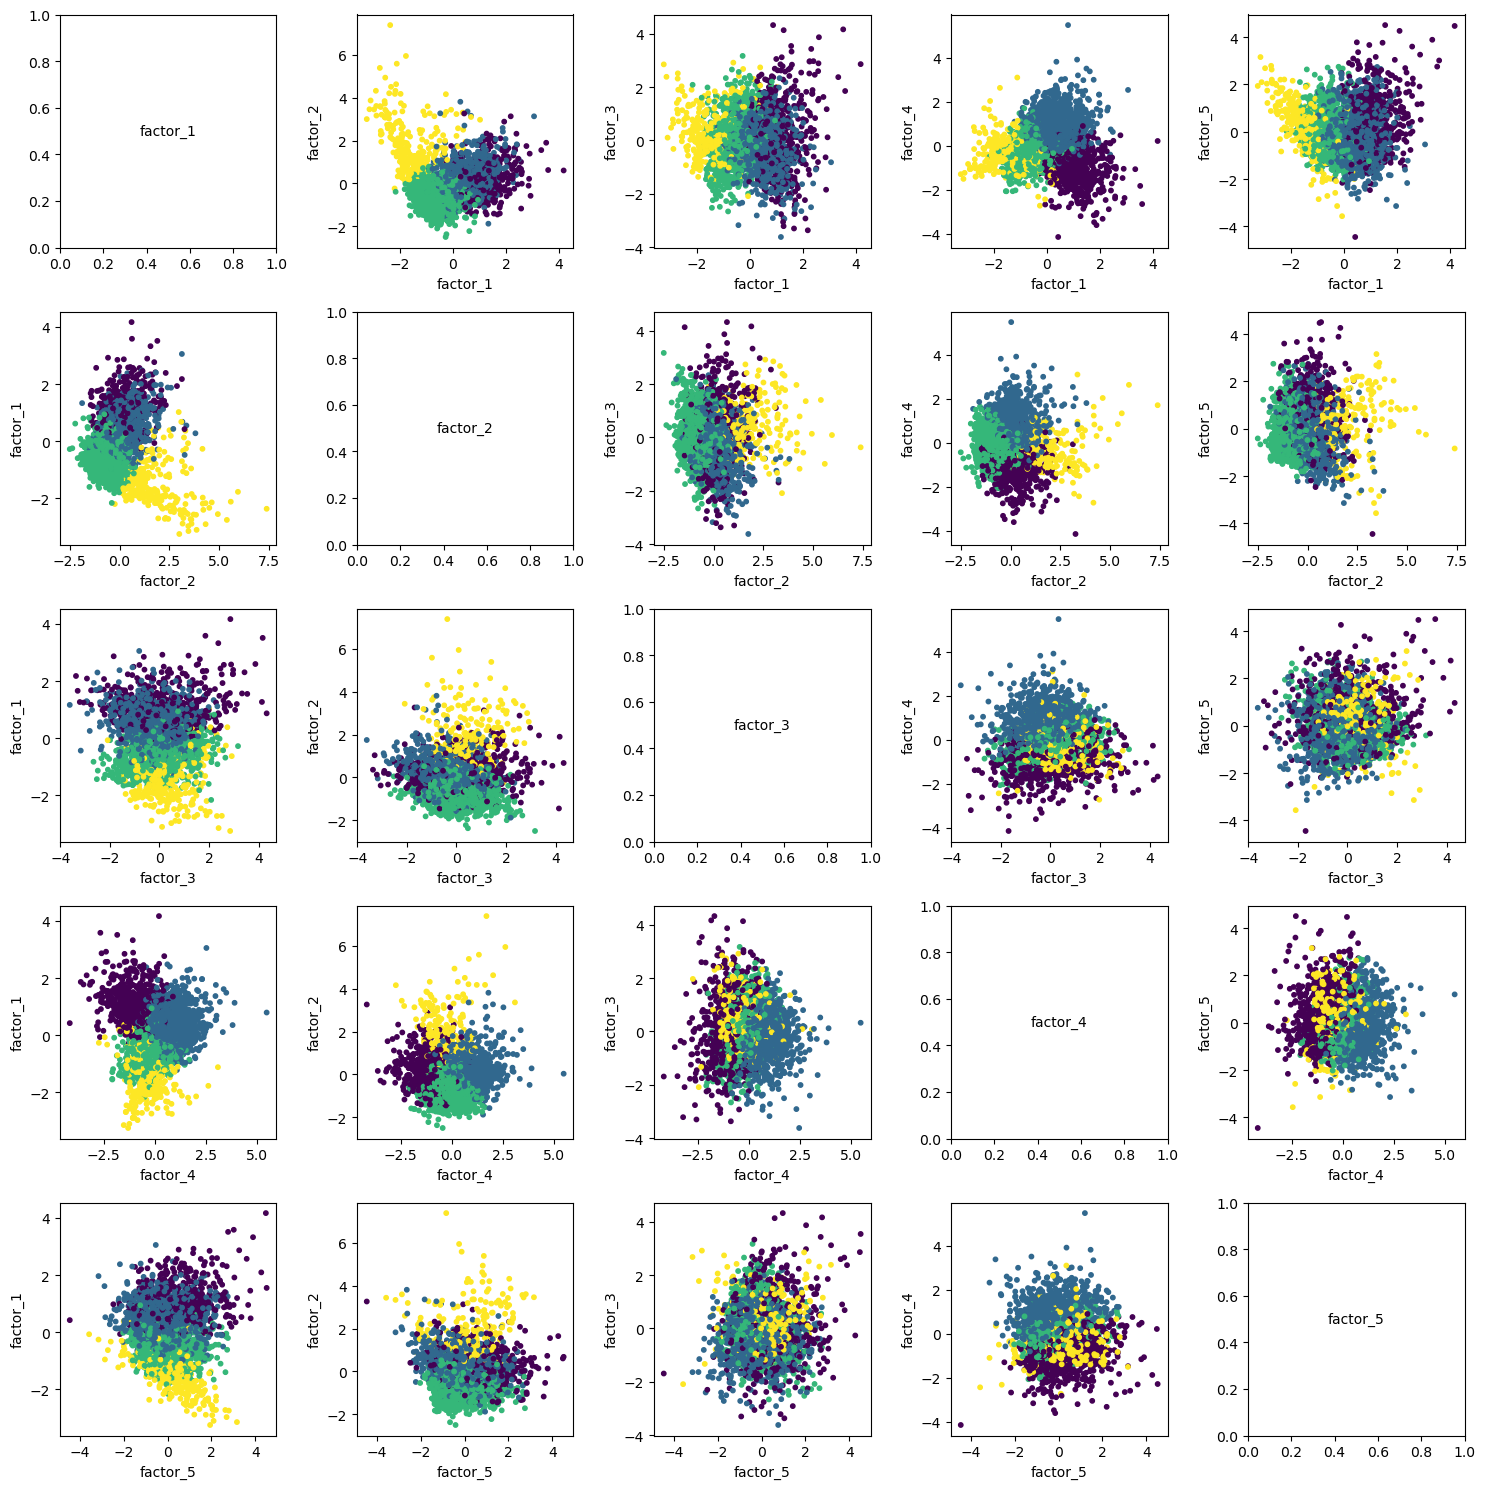

In [124]:
factors = ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
n = len(factors)

fig, axes = plt.subplots(n, n, figsize=(15, 15))

for i in range(n):
    for j in range(n):
        if i != j:
            axes[i, j].scatter(df_normalized[factors[i]], df_normalized[factors[j]], c=df_normalized['cluster'], cmap='viridis', s=10)
            axes[i, j].set_xlabel(factors[i])
            axes[i, j].set_ylabel(factors[j])
        else:
            axes[i, j].text(0.5, 0.5, factors[i], horizontalalignment='center', verticalalignment='center')
        
plt.tight_layout()
plt.show()


**Boxplot for each factor** ('factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5') against the cluster labels. Each boxplot will show the distribution of a single factor across the different clusters. 

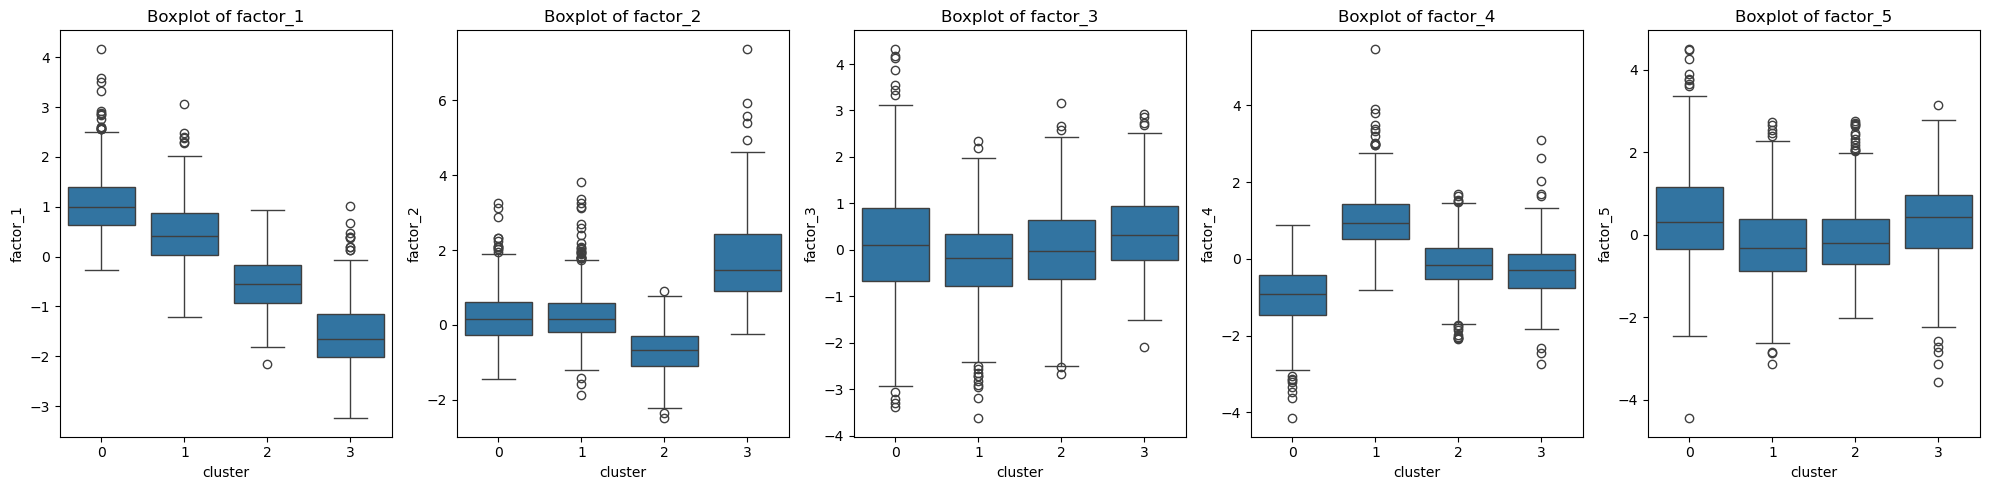

In [125]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, factor in enumerate(['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']):
    sns.boxplot(x='cluster', y=factor, data=df_normalized, ax=axes[i])
    axes[i].set_title(f'Boxplot of {factor}')

plt.tight_layout()
plt.show()


# **3. Regression**

**Regression Model on Housing prices and Socioeconomic - Territorial Indicators**
These regression models aim to investigate the relationship between the parish median housing prices and the set of available socioeconomic and demographic indicators at the parish level.

Multiple or multivariate linear regression is a case of linear regression with two or more independent variables.
- The dependent features are called the dependent variables, outputs, or responses.
- The independent features are called the independent variables, inputs, or predictors.


<span style="color:red">M1:</span>

**Dependent Variable:**
 - *HousPrice_Median_bySquareMeter*: The median housing price per square meter (at the parish level)

**Independent Variables**:
- IVolumetria
- vagos_perc
- IMédia_edif
- aloj_habitual_perc
- dimensao_aloj
- aloj_por_familia
- arrendamento_perc
- divisões_n
- ind_envelhecimento
- ind_migração
- primário_perc
- terciário_perc
        

<span style="color:red">M2:</span>

**Dependent Variable:**
 - *HousPrice_Median_bySquareMeter*: The median housing price per square meter (at the parish level)

**Independent Variables**:
- Factor 1
- Factor 2
- Factor 3
- Factor 4
- Factor 5

<span style="color:red">M3:</span>

**Dependent Variable:**
 - *Ln_HousPrice_Median_bySquareMeter*: The natural log of the median housing price per square meter (at the parish level)

**Independent Variables**:
- IVolumetria
- vagos_perc
- IMédia_edif
- aloj_habitual_perc
- dimensao_aloj
- aloj_por_familia
- arrendamento_perc
- divisões_n-
- ind_envelhecimento
- ind_migração
- primário_perc
- terciário_perc

<span style="color:red">M4:</span>

**Dependent Variable:**
 - *Ln_HousPrice_Median_bySquareMeter*: The natural log of the median housing price per square meter (at the parish level)

**Independent Variables**:
- Factor 1
- Factor 2
- Factor 3
- Factor 4
- Factor 5


**Loading and Merging housing prices data with census data**
The merging is done based on the FREGUESIA column from the df_normalized DataFrame and the Geo_Cod column from the housprice_parish DataFrame. The result is stored in a new DataFrame called df_C21_HousPrice.

In [136]:
df_normalized.columns.tolist()

['IVolumetria',
 'vagos_perc',
 'IMédia_edif',
 'aloj_habitual_perc',
 'dimensao_aloj',
 'aloj_por_familia',
 'arrendamento_perc',
 'divisões_n',
 'degradação_edif_perc',
 'ind_envelhecimento',
 'ind_migração',
 'primário_perc',
 'terciário_perc',
 'NUTS2',
 'NUTS2 DSG',
 'NUTS3',
 'NUTS3 DSG',
 'MUNICIPIO',
 'MUNICIPIO DSG',
 'FREGUESIA',
 'FREGUESIA DSG',
 'factor_1',
 'factor_2',
 'factor_3',
 'factor_4',
 'factor_5',
 'cluster']

In [137]:
housprice = pd.read_excel(r'./data/inputs/INE/Habitacao/Valor mediano das vendas de alojamentos familiares anual fregs.xls', sheet_name='export_parish_data')
housprice

,Geo_Cod_Designa,Geo_Cod,HousPrice_Median_bySquareMeter,Unnamed: 3,Level
0,Continente,1,1778.0,1,1
1,Norte,11,1558.0,11,2
2,Alto Minho,111,1248.0,111,3
3,Arcos de Valdevez,1111601,958.0,1111601,7
4,Caminha,1111602,1425.0,1111602,7
...,...,...,...,...,...
925,Ribeira Brava,3003107,1467.0,3003107,7
926,Santa Cruz,3003108,2269.0,3003108,7
927,Santana,3003109,1023.0,3003109,7
928,São Vicente,3003110,1050.0,3003110,7


In [148]:
housprice.Level.unique()

array([1, 2, 3, 7, 9])

In [149]:
housprice_parish = housprice[housprice.Level == 9]
housprice_parish = housprice_parish[['Geo_Cod', 'Geo_Cod_Designa', 'HousPrice_Median_bySquareMeter']]

In [150]:
housprice_parish.iloc[[0,-1]]

,Geo_Cod,Geo_Cod_Designa,HousPrice_Median_bySquareMeter
16,112030201,Abade de Neiva,1334.0
921,300310309,São Roque,2167.0


In [151]:
housprice_parish['Geo_Cod'] = housprice_parish['Geo_Cod'].str.slice(3)

In [152]:
housprice_parish.iloc[[0,-1]]

,Geo_Cod,Geo_Cod_Designa,HousPrice_Median_bySquareMeter
16,030201,Abade de Neiva,1334.0
921,310309,São Roque,2167.0


In [153]:

df_C21_HousPrice = pd.merge(df_normalized, housprice_parish, how='left', left_on='FREGUESIA', right_on='Geo_Cod')
df_C21_HousPrice

,IVolumetria,vagos_perc,IMédia_edif,aloj_habitual_perc,dimensao_aloj,aloj_por_familia,arrendamento_perc,divisões_n,degradação_edif_perc,ind_envelhecimento,...,FREGUESIA DSG,factor_1,factor_2,factor_3,factor_4,factor_5,cluster,Geo_Cod,Geo_Cod_Designa,HousPrice_Median_bySquareMeter
0,-0.336968,0.058104,0.655330,-0.247299,0.324468,-0.067975,-0.878081,0.097914,-1.355540,-0.032972,...,Aboim das Choças,0.245256,-0.248629,0.697820,0.260693,-1.203092,2,NaN,NaN,NaN
1,-0.204311,-0.322800,-1.367519,-0.067987,0.479618,-0.209009,-0.469833,-0.055348,0.343890,-0.224329,...,Aguiã,-0.119139,-0.825055,-0.172634,-0.429620,0.348500,2,NaN,NaN,NaN
2,-0.328981,-1.105438,0.012797,-0.446915,0.413638,0.108886,-0.725979,0.094450,-0.504155,0.026504,...,Ázere,0.233944,-0.304174,0.799036,-0.607487,-0.185962,2,NaN,NaN,NaN
3,-0.513060,1.330878,0.626144,-1.999745,-0.452004,3.155638,-0.814249,-0.182810,1.131672,2.646014,...,Cabana Maior,2.228442,0.668674,-0.273130,0.125693,1.014989,0,NaN,NaN,NaN
4,-0.351524,0.142011,2.314064,-0.594155,-0.933628,0.255228,-0.841718,-0.949760,2.419048,1.499970,...,Cabreiro,1.048061,0.880063,-1.544345,0.677354,1.930569,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2877,-0.628935,0.673167,-0.367874,0.873746,1.059251,-0.757335,-0.476653,0.226365,-1.428354,-0.576073,...,Aguiar,-0.402200,-0.778300,0.625039,0.784370,-1.546654,2,NaN,NaN,NaN
2878,-0.657104,-0.411339,1.401727,0.435483,-0.831657,-0.538717,1.219738,-1.190785,-0.754453,-0.429842,...,Bencatel,-0.404567,0.519665,-1.306622,-0.604297,-1.056530,2,NaN,NaN,NaN
2879,-0.632600,-0.907962,0.833680,-0.174822,-0.977168,-0.126844,-0.211657,-0.853588,-1.479484,0.060078,...,Ciladas,0.287882,0.312031,-0.541927,-1.499912,-1.391642,0,NaN,NaN,NaN
2880,-0.558200,0.181084,-0.219879,-0.338515,0.160218,0.010020,0.102574,-0.620962,-1.498536,-0.398060,...,Pardais,-0.018084,-0.073701,0.016751,-0.480339,-1.684452,2,NaN,NaN,NaN


In [154]:
df_C21_HousPrice.dtypes

IVolumetria                       float64
vagos_perc                        float64
IMédia_edif                       float64
aloj_habitual_perc                float64
dimensao_aloj                     float64
aloj_por_familia                  float64
arrendamento_perc                 float64
divisões_n                        float64
degradação_edif_perc              float64
ind_envelhecimento                float64
ind_migração                      float64
primário_perc                     float64
terciário_perc                    float64
NUTS2                             float64
NUTS2 DSG                          object
NUTS3                              object
NUTS3 DSG                          object
MUNICIPIO                         float64
MUNICIPIO DSG                      object
FREGUESIA                          object
FREGUESIA DSG                      object
factor_1                          float64
factor_2                          float64
factor_3                          

In [155]:
df_C21_HousPrice['HousPrice_Median_bySquareMeter']

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
2877   NaN
2878   NaN
2879   NaN
2880   NaN
2881   NaN
Name: HousPrice_Median_bySquareMeter, Length: 2882, dtype: float64

In [161]:
df_C21_HousPrice_withoutnan = df_C21_HousPrice[~df_C21_HousPrice['HousPrice_Median_bySquareMeter'].isna()]
df_C21_HousPrice_withoutnan.shape   

(329, 30)

## M1: HousPrice = f(indicators)

In [162]:
# Select independent variables
X1 = df_C21_HousPrice_withoutnan[['IVolumetria', 'vagos_perc', 'IMédia_edif', 'aloj_habitual_perc', 
        'dimensao_aloj', 'aloj_por_familia', 'arrendamento_perc', 
        'divisões_n',  'degradação_edif_perc', 'ind_envelhecimento', 'ind_migração', 
        'primário_perc', 'terciário_perc']]

# Select dependent variable
y1 = df_C21_HousPrice_withoutnan['HousPrice_Median_bySquareMeter']

In [163]:
# Add a constant to the independent variable set to represent the intercept
X1 = sm.add_constant(X1)

# Fit the model
model1 = sm.OLS(y1, X1).fit()

# Print out the statistics
print(model1.summary())


                                  OLS Regression Results                                  
Dep. Variable:     HousPrice_Median_bySquareMeter   R-squared:                       0.716
Model:                                        OLS   Adj. R-squared:                  0.705
Method:                             Least Squares   F-statistic:                     61.22
Date:                            Thu, 11 Dec 2025   Prob (F-statistic):           4.76e-78
Time:                                    22:39:25   Log-Likelihood:                -2534.0
No. Observations:                             329   AIC:                             5096.
Df Residuals:                                 315   BIC:                             5149.
Df Model:                                      13                                         
Covariance Type:                        nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-

**Coefficient Plot**
To visualize the coefficients, you can create a bar plot.

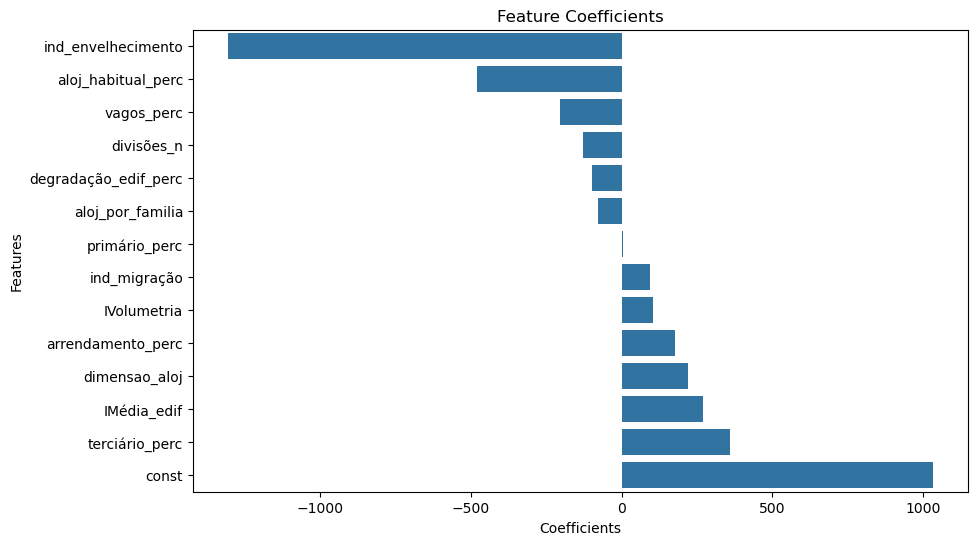

In [164]:
coefficients1 = pd.DataFrame({'Features': X1.columns, 'Coefficients': model1.params})
coefficients1 = coefficients1.sort_values(by='Coefficients')

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficients', y='Features', data=coefficients1)
plt.title('Feature Coefficients')
plt.show()


**Plotting Residuals**
Plot the residuals (i.e., the difference between the observed and predicted values) to check if they are normally distributed and if there are any patterns. This can be a good diagnostic tool.

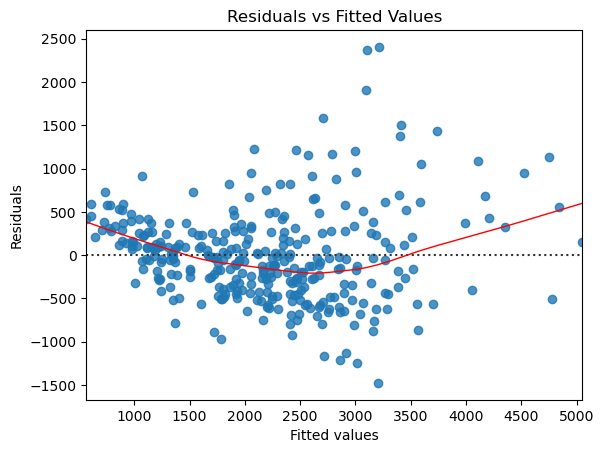

In [165]:
# Calculate residuals
residuals1 = y1 - model1.predict(X1)

# Create a seaborn residual plot
sns.residplot(x=model1.predict(X1), y=residuals1, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()


**Scatter Plot of Predicted vs Actual Values**
A scatter plot of predicted vs actual values can give you an idea of how well your model is performing

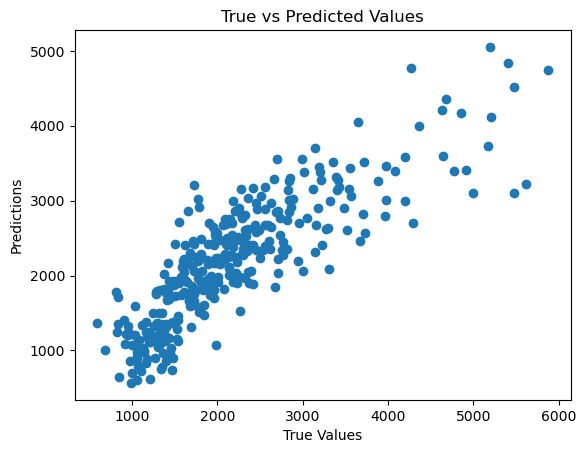

In [166]:
plt.scatter(y1, model1.predict(X1))
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()


**QQ Plot**
A QQ plot can help you assess if the residuals are normally distributed, which is one of the assumptions of linear regression.



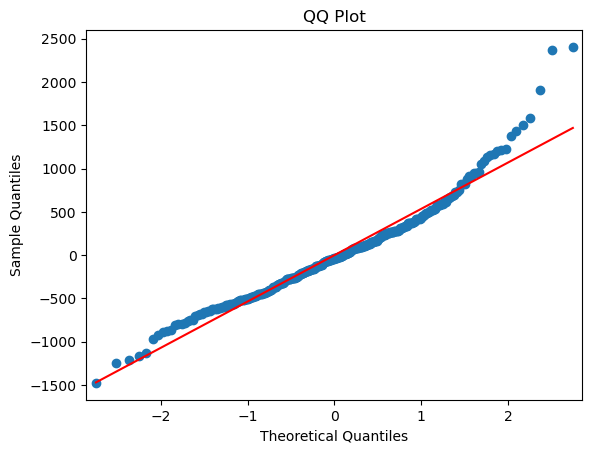

In [167]:
# QQ_Plot
sm.qqplot(residuals1, line='s')
plt.title('QQ Plot')
plt.show()


## M2: HousPrice = f(factors)

In [171]:
# Select independent variables
X2 = df_C21_HousPrice_withoutnan[['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']]

# Select dependent variable
y2 = df_C21_HousPrice_withoutnan['HousPrice_Median_bySquareMeter']

In [172]:
# Add a constant to the independent variable set to represent the intercept
X2 = sm.add_constant(X2)

# Fit the model
model2 = sm.OLS(y2, X2).fit()

# Print out the statistics
print(model2.summary())


                                  OLS Regression Results                                  
Dep. Variable:     HousPrice_Median_bySquareMeter   R-squared:                       0.653
Model:                                        OLS   Adj. R-squared:                  0.647
Method:                             Least Squares   F-statistic:                     121.4
Date:                            Thu, 11 Dec 2025   Prob (F-statistic):           5.70e-72
Time:                                    22:42:48   Log-Likelihood:                -2567.4
No. Observations:                             329   AIC:                             5147.
Df Residuals:                                 323   BIC:                             5170.
Df Model:                                       5                                         
Covariance Type:                        nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------

**Coefficient Plot**
To visualize the coefficients, you can create a bar plot.

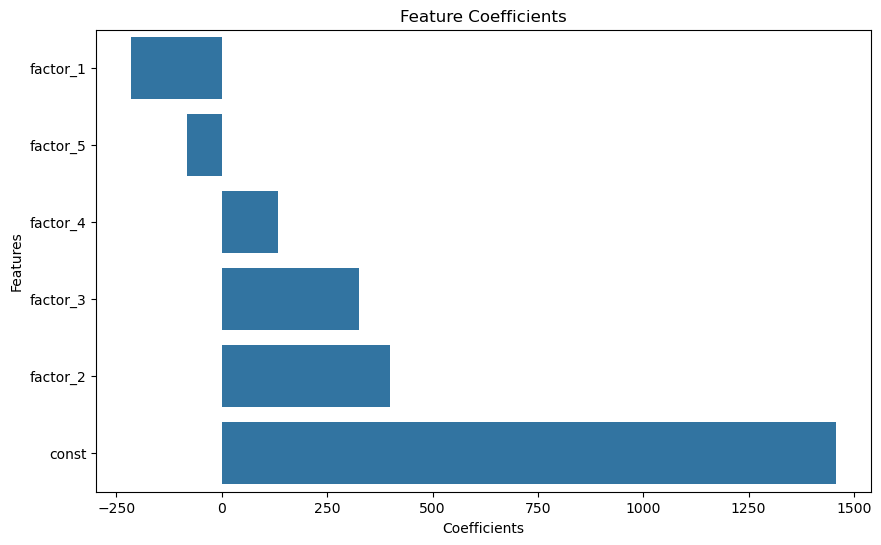

In [173]:
coefficients2 = pd.DataFrame({'Features': X2.columns, 'Coefficients': model2.params})
coefficients2 = coefficients2.sort_values(by='Coefficients')

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficients', y='Features', data=coefficients2)
plt.title('Feature Coefficients')
plt.show()


**Plotting Residuals**
Plot the residuals (i.e., the difference between the observed and predicted values) to check if they are normally distributed and if there are any patterns. This can be a good diagnostic tool.

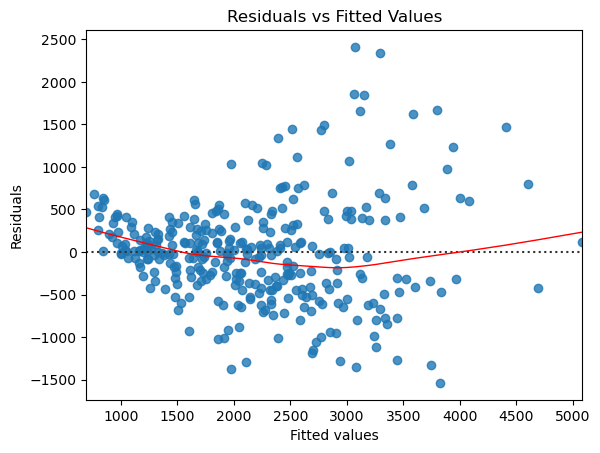

In [174]:
# Calculate residuals
residuals2 = y2 - model2.predict(X2)

# Create a seaborn residual plot
sns.residplot(x=model2.predict(X2), y=residuals2, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()


**Scatter Plot of Predicted vs Actual Values**
A scatter plot of predicted vs actual values can give you an idea of how well your model is performing

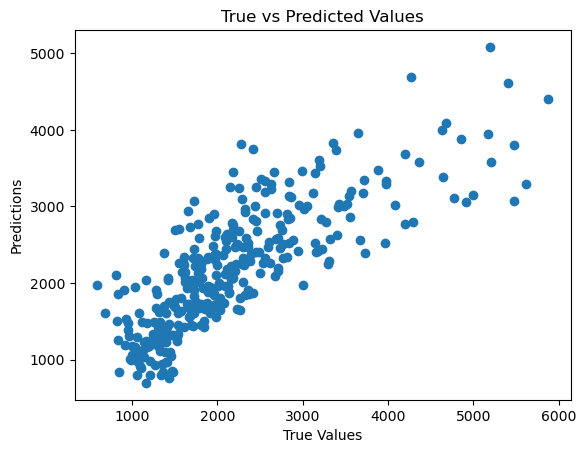

In [175]:
plt.scatter(y2, model2.predict(X2))
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()


**QQ Plot**
A QQ plot can help you assess if the residuals are normally distributed, which is one of the assumptions of linear regression.



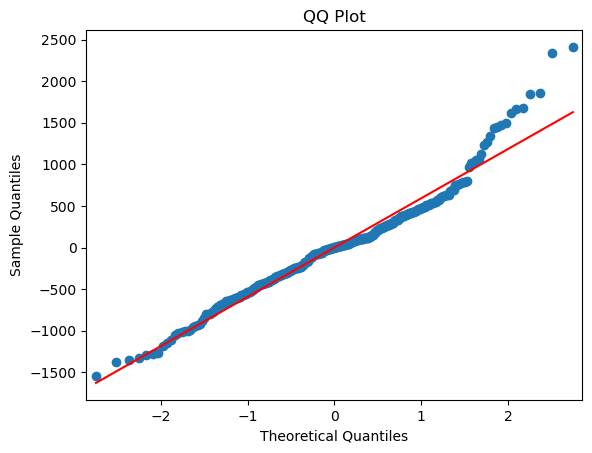

In [176]:
# QQ_Plot
sm.qqplot(residuals2, line='s')
plt.title('QQ Plot')
plt.show()


## M3: LnHousPrice = f(indicators)

<Axes: >

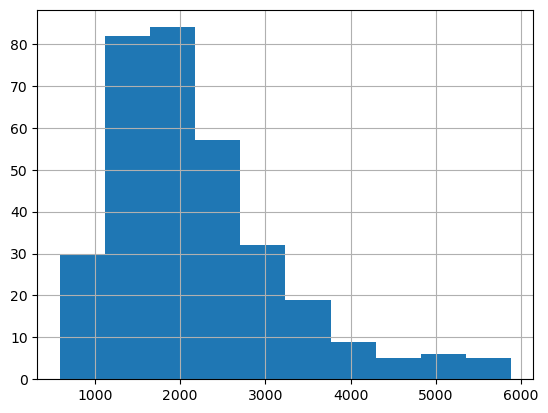

In [168]:
df_C21_HousPrice_withoutnan['HousPrice_Median_bySquareMeter'].hist()

In [169]:
df_C21_HousPrice_withoutnan['LnHousPrice_Median_bySquareMeter'] = np.log(df_C21_HousPrice_withoutnan['HousPrice_Median_bySquareMeter'])

C:\Users\paulo\AppData\Local\Temp\ipykernel_4228\2657988526.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_C21_HousPrice_withoutnan['LnHousPrice_Median_bySquareMeter'] = np.log(df_C21_HousPrice_withoutnan['HousPrice_Median_bySquareMeter'])


<Axes: >

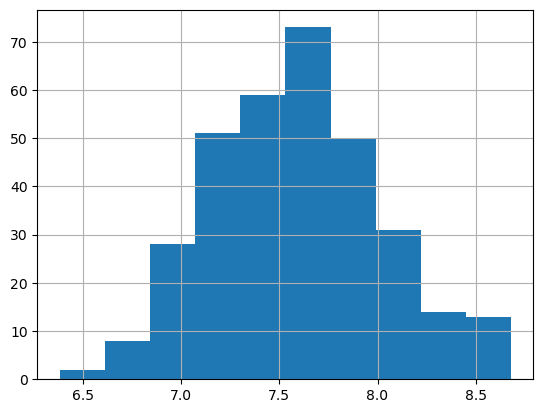

In [170]:
df_C21_HousPrice_withoutnan['LnHousPrice_Median_bySquareMeter'].hist()

In [177]:
# Select independent variables
X3 = df_C21_HousPrice_withoutnan[['IVolumetria', 'vagos_perc', 'IMédia_edif', 'aloj_habitual_perc', 
        'dimensao_aloj', 'aloj_por_familia', 'arrendamento_perc', 
        'divisões_n', 'ind_envelhecimento', 'ind_migração', 
        'primário_perc', 'terciário_perc']]

# Select dependent variable
y3 = df_C21_HousPrice_withoutnan['LnHousPrice_Median_bySquareMeter']

In [178]:
# Add a constant to the independent variable set to represent the intercept
X3 = sm.add_constant(X3)

# Fit the model
model3 = sm.OLS(y3, X3).fit()

# Print out the statistics
print(model3.summary())


                                   OLS Regression Results                                   
Dep. Variable:     LnHousPrice_Median_bySquareMeter   R-squared:                       0.771
Model:                                          OLS   Adj. R-squared:                  0.762
Method:                               Least Squares   F-statistic:                     88.62
Date:                              Thu, 11 Dec 2025   Prob (F-statistic):           1.88e-93
Time:                                      22:43:24   Log-Likelihood:                 52.498
No. Observations:                               329   AIC:                            -79.00
Df Residuals:                                   316   BIC:                            -29.65
Df Model:                                        12                                         
Covariance Type:                          nonrobust                                         
                         coef    std err          t      P>|t|      [0

**Coefficient Plot**
To visualize the coefficients, you can create a bar plot.

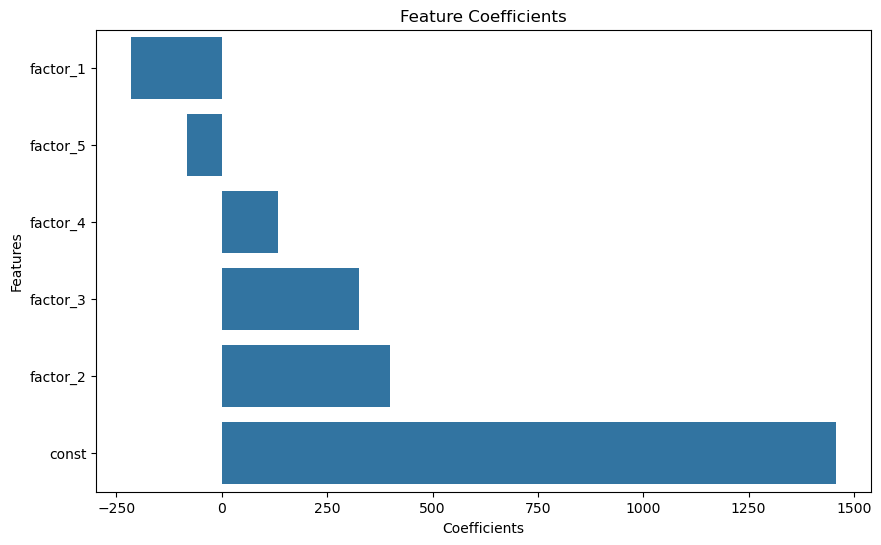

In [179]:
coefficients3 = pd.DataFrame({'Features': X3.columns, 'Coefficients': model3.params})
coefficients3 = coefficients2.sort_values(by='Coefficients')

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficients', y='Features', data=coefficients3)
plt.title('Feature Coefficients')
plt.show()


**Plotting Residuals**
Plot the residuals (i.e., the difference between the observed and predicted values) to check if they are normally distributed and if there are any patterns. This can be a good diagnostic tool.

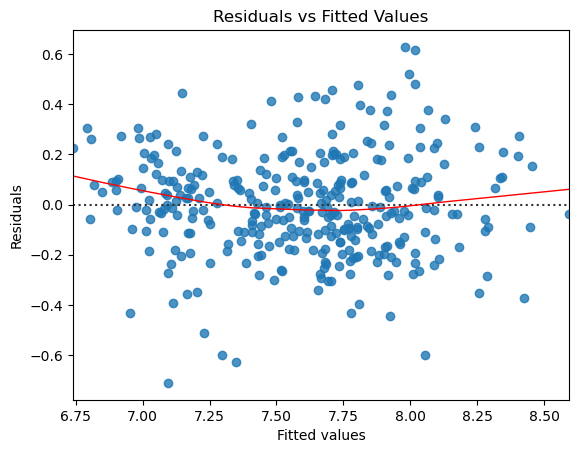

In [180]:
# Calculate residuals
residuals3 = y3 - model3.predict(X3)

# Create a seaborn residual plot
sns.residplot(x=model3.predict(X3), y=residuals3, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()


**Scatter Plot of Predicted vs Actual Values**
A scatter plot of predicted vs actual values can give you an idea of how well your model is performing

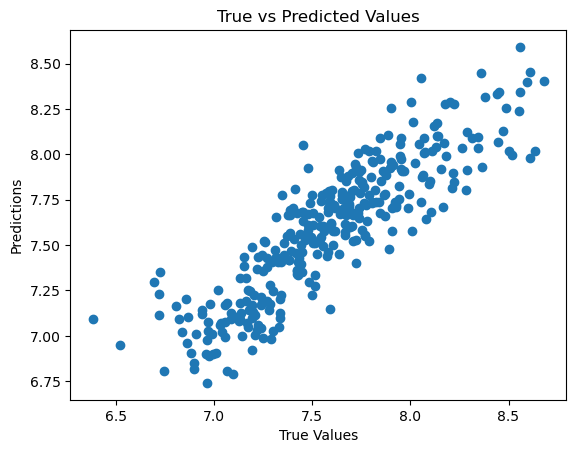

In [181]:
plt.scatter(y3, model3.predict(X3))
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()


**QQ Plot**
A QQ plot can help you assess if the residuals are normally distributed, which is one of the assumptions of linear regression.



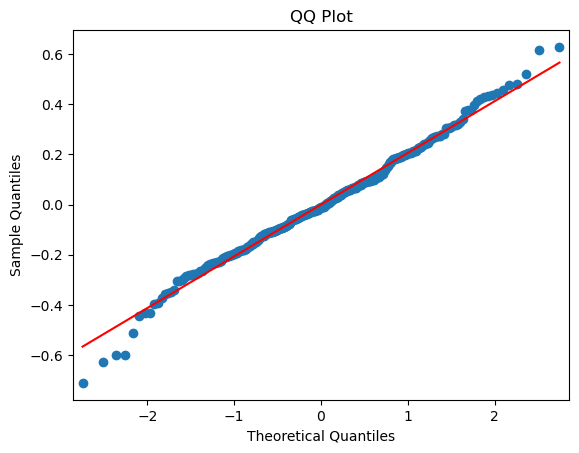

In [182]:
# QQ_Plot
sm.qqplot(residuals3, line='s')
plt.title('QQ Plot')
plt.show()


## M4: LnHousPrice = f(factors)

In [183]:
# Select independent variables
X4 = df_C21_HousPrice_withoutnan[['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']]

# Select dependent variable
y4 = df_C21_HousPrice_withoutnan['LnHousPrice_Median_bySquareMeter']

In [184]:
# Add a constant to the independent variable set to represent the intercept
X4 = sm.add_constant(X4)

# Fit the model
model4 = sm.OLS(y4, X4).fit()

# Print out the statistics
print(model4.summary())


                                   OLS Regression Results                                   
Dep. Variable:     LnHousPrice_Median_bySquareMeter   R-squared:                       0.679
Model:                                          OLS   Adj. R-squared:                  0.674
Method:                               Least Squares   F-statistic:                     136.6
Date:                              Thu, 11 Dec 2025   Prob (F-statistic):           1.87e-77
Time:                                      22:44:44   Log-Likelihood:                -3.0604
No. Observations:                               329   AIC:                             18.12
Df Residuals:                                   323   BIC:                             40.90
Df Model:                                         5                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

**Coefficient Plot**
To visualize the coefficients, you can create a bar plot.

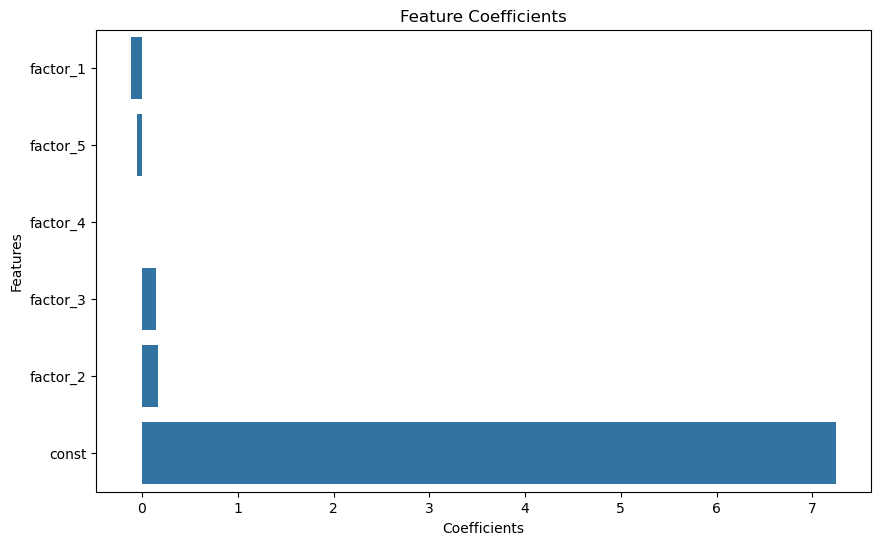

In [185]:
coefficients4 = pd.DataFrame({'Features': X4.columns, 'Coefficients': model4.params})
coefficients4 = coefficients4.sort_values(by='Coefficients')

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficients', y='Features', data=coefficients4)
plt.title('Feature Coefficients')
plt.show()


**Plotting Residuals**
Plot the residuals (i.e., the difference between the observed and predicted values) to check if they are normally distributed and if there are any patterns. This can be a good diagnostic tool.

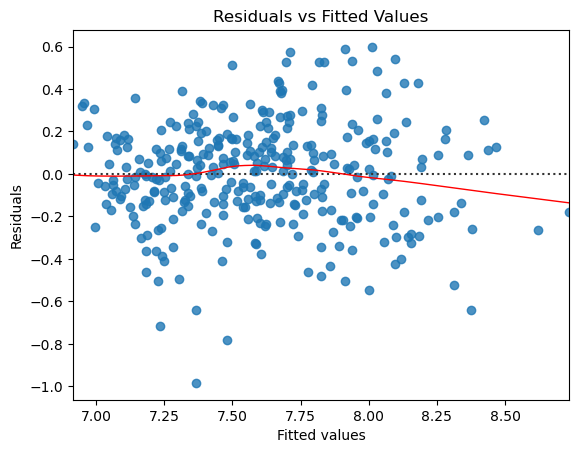

In [186]:
# Calculate residuals
residuals4 = y4 - model4.predict(X4)

# Create a seaborn residual plot
sns.residplot(x=model4.predict(X4), y=residuals4, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()


**Scatter Plot of Predicted vs Actual Values**
A scatter plot of predicted vs actual values can give you an idea of how well your model is performing

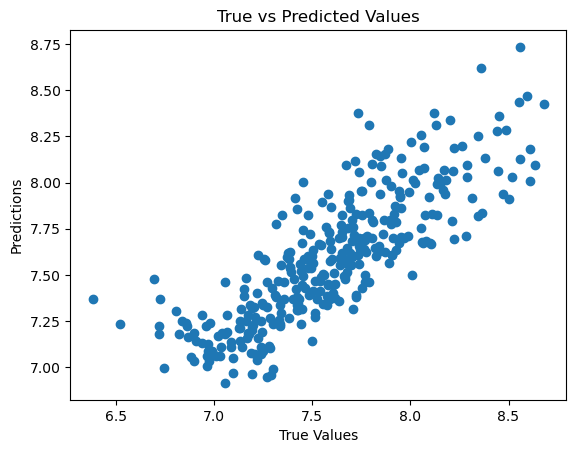

In [187]:
plt.scatter(y4, model4.predict(X4))
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()


**QQ Plot**
A QQ plot can help you assess if the residuals are normally distributed, which is one of the assumptions of linear regression.



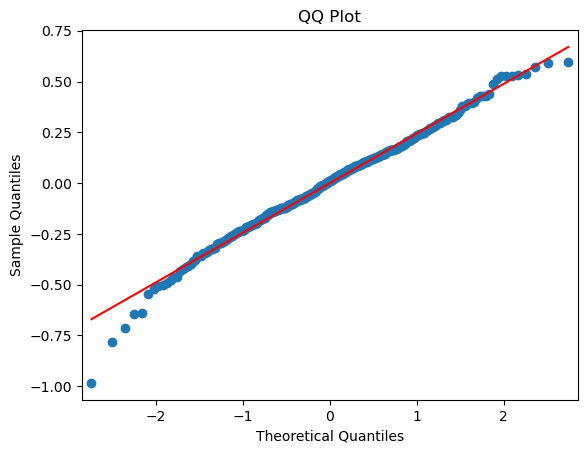

In [188]:
# QQ_Plot
sm.qqplot(residuals4, line='s')
plt.title('QQ Plot')
plt.show()
